# Clasificación de la Estabilidad de un Sistema Hidráulico Complejo mediante LSTM y GRU

Este notebook implementa y evalúa modelos de redes neuronales recurrentes 
(**LSTM** y **GRU**) para clasificar la estabilidad de un sistema hidráulico 
complejo a partir de series temporales multivariadas de sensores.

**Integrantes:**
- Corcuera Araujo, Carlos Bitner
- Mendoza Pascual, Lady Alexandra
- Huamán Huamán, William Fabián
- Rojas Guarniz, Josias Natan
- Rocha Montoya, Carlos Adrián


In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

## 1. Importación de librerías

Se importan las librerías necesarias para el procesamiento de datos, 
construcción de modelos y visualización de resultados.


In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import torch  # reemplaza tensorflow

# Esto debe ir ANTES de importar keras
os.environ["KERAS_BACKEND"] = "torch"

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix,
                             precision_recall_curve, average_precision_score, auc)

from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout, GRU
from keras import regularizers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 2. Configuración del dispositivo de cómputo

Se detecta automáticamente si hay una GPU disponible para acelerar el entrenamiento. 
Si no se encuentra ninguna, el entrenamiento se ejecuta en CPU sin necesidad de cambiar nada en el código.


In [3]:
# ── Detección automática de GPU / CPU ─────────────────────────────────────────
if torch.cuda.is_available():
    # Habilitar crecimiento dinámico de memoria para evitar reservar toda la VRAM
    torch.cuda.set_per_process_memory_fraction(0.9)  # usa hasta 90% de VRAM
    DEVICE = 'cuda'
    gpu_name = torch.cuda.get_device_name(0)
    print(f'✓ GPU detectada: {gpu_name}')
    print(f'  Entrenamiento acelerado en: {DEVICE}')
else:
    DEVICE = 'cpu'
    print('⚠ No se detectó GPU. Entrenamiento en CPU.')
    print(f'  Dispositivo: {DEVICE}')

print(f'\nVersión de PyTorch: {torch.__version__}')
print(f'GPUs disponibles: {torch.cuda.device_count()}')

✓ GPU detectada: NVIDIA GeForce RTX 2060 with Max-Q Design
  Entrenamiento acelerado en: cuda

Versión de PyTorch: 2.1.0+cu121
GPUs disponibles: 1


## 3. Carga de datos preprocesados

Se cargan los archivos de series temporales ya filtradas y normalizadas, 
correspondientes a cada sensor del sistema hidráulico.


In [4]:
# Lista de archivos parquet
file_list = [
    './processed/PS1_filtrados.parquet',
    './processed/PS2_filtrados.parquet',
    './processed/PS3_filtrados.parquet',
    './processed/PS4_filtrados.parquet',
    './processed/PS5_filtrados.parquet',
    './processed/PS6_filtrados.parquet',
    './processed/EPS1_filtrados.parquet',
    './processed/FS1_filtrados.parquet',
    './processed/FS2_filtrados.parquet',
    './processed/TS1_filtrados.parquet',
    './processed/TS2_filtrados.parquet',
    './processed/TS3_filtrados.parquet',
    './processed/TS4_filtrados.parquet',
    './processed/VS1_filtrados.parquet',
    './processed/CE_filtrados.parquet',
    './processed/CP_filtrados.parquet',
    './processed/SE_filtrados.parquet'
]

In [5]:
# Creamos etiquetas para los targets
targets_names = ["cooler", "valve", "leakage", "accumulator", "stable"]

# Función para leer parquet y devolver numpy array
def file_read(file):
    return pd.read_parquet(file).to_numpy()

### Verificación de dimensiones por sensor

Se imprime el nombre de cada sensor junto con las dimensiones de su matriz de datos, 
para confirmar que la carga fue correcta.


In [6]:
data_dict = {}  # Diccionario para almacenar sensor con su respectiva data

for file in file_list:
    data = file_read(file)

    if np.isnan(data[0]).all():
        data = data[1:]  # Eliminar la primera fila

    data = data.T

    file_name = file.split('/')[-1]
    file_ = file_name.split('.')[0]

    print(file_, data.shape)

    data_dict[file_] = data

# Leer targets
ans_df = pd.read_parquet('./processed/profile.parquet')
ans_df.columns = targets_names

PS1_filtrados (2205, 6000)
PS2_filtrados (2205, 6000)
PS3_filtrados (2205, 6000)
PS4_filtrados (2205, 6000)
PS5_filtrados (2205, 6000)
PS6_filtrados (2205, 6000)
EPS1_filtrados (2205, 6000)
FS1_filtrados (2205, 600)
FS2_filtrados (2205, 600)
TS1_filtrados (2205, 60)
TS2_filtrados (2205, 60)
TS3_filtrados (2205, 60)
TS4_filtrados (2205, 60)
VS1_filtrados (2205, 60)
CE_filtrados (2205, 60)
CP_filtrados (2205, 60)
SE_filtrados (2205, 60)


## 4. Descripción del conjunto de datos

El dataset proviene del banco de pruebas hidráulico del Centre for Mechatronics and Automation Technology 
(Saarbrücken, Alemania) y está disponible públicamente en el UCI Machine Learning Repository.

**Características generales:**
- **Instancias:** 2,205 ciclos de operación de 60 segundos cada uno
- **Sensores:** 17 sensores a distintas frecuencias de muestreo (1 Hz, 10 Hz, 100 Hz)
- **Variables de entrada:** tensores 3D de forma `(2205, 56, 17)` tras el preprocesamiento

**Sensores incluidos:**

| Grupo | Sensores | Frecuencia | Muestras por ciclo |
|-------|----------|------------|--------------------|
| Presión | PS1–PS6 | 100 Hz | 6,000 |
| Potencia de motor | EPS1 | 100 Hz | 6,000 |
| Flujo volumétrico | FS1, FS2 | 10 Hz | 600 |
| Temperatura | TS1–TS4 | 1 Hz | 60 |
| Vibración | VS1 | 1 Hz | 60 |
| Factor de eficiencia | SE | 1 Hz | 60 |
| Eficiencia de refrigeración | CE | 1 Hz | 60 |
| Potencia de refrigeración | CP | 1 Hz | 60 |

**Variable objetivo — `stable`:**

| Valor | Significado | Instancias |
|-------|-------------|------------|
| `0` | Condiciones estables alcanzadas | 1,449 |
| `1` | Condiciones estáticas posiblemente no alcanzadas | 756 |

> El desbalance de clases (~65.6% / 34.4%) se maneja durante el entrenamiento 
> mediante ponderación de clases (`class_weight='balanced'`).


## 5. Variable objetivo

El target de clasificación es `stable`, que indica si el sistema alcanzó 
condiciones de operación estables al final del ciclo de medición.


## 6. Construcción del tensor de entrada

Se define la función `create_time_data` que transforma el diccionario de sensores en un 
tensor 3D de forma `(n_instancias, pasos_de_tiempo, n_sensores)`, 
aplicando remuestreo y suavizado mediante convolución con ventana deslizante.


In [7]:
def create_time_data(data_dict, window_size=1): # Crea una función que recive el diccionario de los sensores y un window size
    x = None                                    # Se inicializa la variable x en none para que luego reciva los valores transformados
    for key in data_dict:                       # Se itera sobre cada item en el diccionario: PS1, PS2, PS3, ..., SE
        v = data_dict[key]                      # Se obtiene el array de valores de cada sensor (v) y se remuestrea
        if v.shape[1] == 6000:                  # Se coje cada 100avo valor, pasando de 6000 datos a 60
            v = v[:,::100]
        elif v.shape[1] == 600:                 # Se coje cada 10mo valor, pasando de 600 datos a 60
            v = v[:,::10]
        assert v.shape[1] == 60                 # Si se cumple el programa sigue, sino, se detiene indicando error en la data

        v = np.apply_along_axis(lambda x: np.convolve(x, np.ones(window_size)/window_size, mode='valid'), axis = 1, arr=v) # Realiza una convolución a lo largo de cada fila de la matriz v para suavizado
        scaler = MinMaxScaler()                 # Escalamiento de la data
        v = scaler.fit_transform(v)

        if x is None:
            x = v.reshape(1,2205,61 - window_size)                            # Si es la primera iteración se establece igual a v después de remodelarla
        else:
            x = np.concatenate((x,v.reshape(1,2205,61 - window_size )))       # Si no es la primera iteración, se concatena a x
    x = np.transpose(x,(1,2,0))                                               # La transposición se realiza para cambiar el orden de las dimensiones y tener una forma final de (longitud_temporal_después_del_procesamiento, 1, número_de_series_temporales).
    return x

In [8]:
x = create_time_data(data_dict, window_size=5)
y = ans_df['stable'].values

In [9]:
print(x.shape)
print(y.shape)

(2205, 56, 17)
(2205,)


## 7. División del conjunto de datos

Los datos se dividen en tres subconjuntos con proporciones fijas y estratificadas 
para preservar la distribución de clases en cada partición.


In [10]:
# ── División de datos: 70% entrenamiento / 15% validación / 15% backtesting ───
#
#  | Conjunto      | % | Uso                                              |
#  |---------------|---|--------------------------------------------------|
#  | x_train       |70%| Ajuste de pesos del modelo                       |
#  | x_val         |15%| Monitoreo de sobreajuste en model.fit()          |
#  | x_backtest    |15%| Evaluación final — datos NUNCA vistos por modelo |
#
# Estrategia:
#   Paso 1 — separar 30% como 'holdout' (estratificado)
#   Paso 2 — dividir el holdout 50/50 -> x_val (15%) y x_backtest (15%)

# Paso 1: train 70% / holdout 30%
x_train, x_holdout, y_train, y_holdout = train_test_split(
    x, y, test_size=0.30, random_state=42, stratify=y
)
# Paso 2: holdout -> val 15% / backtest 15%
x_val, x_backtest, y_val, y_backtest = train_test_split(
    x_holdout, y_holdout, test_size=0.50, random_state=42, stratify=y_holdout
)

print(f'Entrenamiento : {x_train.shape[0]:>5} muestras  ({x_train.shape[0]/len(y)*100:.1f}%)')
print(f'Validación    : {x_val.shape[0]:>5} muestras  ({x_val.shape[0]/len(y)*100:.1f}%)')
print(f'Backtesting   : {x_backtest.shape[0]:>5} muestras  ({x_backtest.shape[0]/len(y)*100:.1f}%)')
print()
print(f'y_train     0:{(y_train==0).sum()}  1:{(y_train==1).sum()}')
print(f'y_val       0:{(y_val==0).sum()}    1:{(y_val==1).sum()}')
print(f'y_backtest  0:{(y_backtest==0).sum()}    1:{(y_backtest==1).sum()}')


Entrenamiento :  1543 muestras  (70.0%)
Validación    :   331 muestras  (15.0%)
Backtesting   :   331 muestras  (15.0%)

y_train     0:1014  1:529
y_val       0:218    1:113
y_backtest  0:217    1:114


## 8. Estilo visual de las gráficas

Se define un estilo uniforme para todas las visualizaciones del notebook.


In [11]:
plt.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
})


## 9. Ponderación de clases

El conjunto de datos presenta un desbalance de aproximadamente **65.6% instancias inestables (0)** 
frente a **34.4% estables (1)**.

Para compensar este desbalance sin generar datos sintéticos, se utiliza 
`class_weight='balanced'`, que asigna un mayor peso al error cometido en la 
clase minoritaria durante el cálculo de la función de pérdida.

Esta estrategia es preferible a técnicas como SMOTE en series temporales, 
ya que la síntesis de muestras puede distorsionar las dependencias temporales 
que el modelo necesita aprender.


In [12]:
clases        = np.unique(y_train)
pesos         = compute_class_weight('balanced', classes=clases, y=y_train)
class_weights = dict(zip(clases, pesos))
print('Pesos de clase:', class_weights)


Pesos de clase: {0: 0.7608481262327417, 1: 1.4584120982986768}


In [13]:
import os
os.makedirs('models', exist_ok=True)
print('Carpeta models/ lista.')


Carpeta models/ lista.


---

# Modelos LSTM

Las redes LSTM (*Long Short-Term Memory*) son un tipo de red neuronal recurrente 
diseñada para capturar dependencias temporales de largo alcance. 
Su arquitectura incluye compuertas de entrada, olvido y salida que regulan 
el flujo de información a través del tiempo.

## Flujo de implementación

```
Remuestreo de la data           Entrenamiento del modelo LSTM
(según su frecuencia)                        ↓
        ↓                        Métricas de rendimiento
Creación del conjunto              (conjunto de validación — 15%)
de entrada y salida                          ↓
(x: tensor 3D, y: 1D)           Gráficas de rendimiento
        ↓                          (Exactitud y Pérdida)
División de los datos                        ↓
  70% entrenamiento               Gráfica de predicciones
  15% validación                    (Real vs Predicción)
  15% backtesting (datos no vistos)          ↓
        ↓                          Matriz de confusión
Creación de la red LSTM
(capas recurrentes, dropout, densa)
```

## Configuraciones evaluadas

Se entrenaron 5 configuraciones con distintos valores de tasa de aprendizaje, 
profundidad de la red, regularización y dropout, buscando identificar 
la combinación que ofrece el mejor equilibrio entre exactitud y generalización.

A cada experimento se le aplicaron las siguientes estrategias de estabilización:
- **`EarlyStopping`** con `patience=15` y restauración de los mejores pesos
- **`ReduceLROnPlateau`** con `factor=0.5` y `patience=7`


### LSTM — Configuración 1

Configuración base sin regularización. Sirve como línea de referencia 
para comparar el efecto de agregar regularización en las siguientes configuraciones.


In [14]:
# ── Experimento 1 LSTM ───────────────────────────────────────────────────────
optimizer_lstm_1 = Adam(learning_rate=0.001)
model_lstm_1 = Sequential(name='lstm_exp1')
model_lstm_1.add(LSTM(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2])))
model_lstm_1.add(Dropout(0.2))
model_lstm_1.add(LSTM(64, return_sequences=False))
model_lstm_1.add(Dropout(0.2))
model_lstm_1.add(Dense(1, activation='sigmoid'))
model_lstm_1.compile(optimizer=optimizer_lstm_1,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_lstm_1 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  LSTM — Experimento 1  |  Dispositivo: {DEVICE}')
print(f'  lr=0.001 | épocas=50 | capas=2 | dropout=0.2 | L1=0 | L2=0')
print(f'{"="*55}')
history_lstm_1 = model_lstm_1.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_lstm_1,
    verbose=1
)

model_lstm_1.save(f'models/modelo_lstm_exp1.keras')
print(f'\nModelo guardado: models/modelo_lstm_exp1.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  LSTM — Experimento 1  |  Dispositivo: cuda
  lr=0.001 | épocas=50 | capas=2 | dropout=0.2 | L1=0 | L2=0
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 260ms/step - accuracy: 0.5916 - loss: 0.6678 - val_accuracy: 0.6103 - val_loss: 0.5438 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step - accuracy: 0.6780 - loss: 0.5556 - val_accuracy: 0.8308 - val_loss: 0.3877 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.7946 - loss: 0.4758 - val_accuracy: 0.8761 - val_loss: 0.3114 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 298ms/step - accuracy: 0.8243 - loss: 0.4391 - val_accuracy: 0.8792 - val_loss: 0.3275 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 265ms/step - accuracy: 0.8925 - loss: 0.3210 - val_accuracy: 0.8520 - val_loss: 0.4286 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.8538 - loss: 0.3690 - val_accuracy: 0.9094 - val_loss: 0.2524

LSTM Exp 1 — Exactitud  (Accuracy):  0.9215
LSTM Exp 1 — Precisión  (Precision): 0.8783
LSTM Exp 1 — Recall:                 0.8938
LSTM Exp 1 — F1-Score:               0.8860
LSTM Exp 1 — AUC-PR:                 0.9675


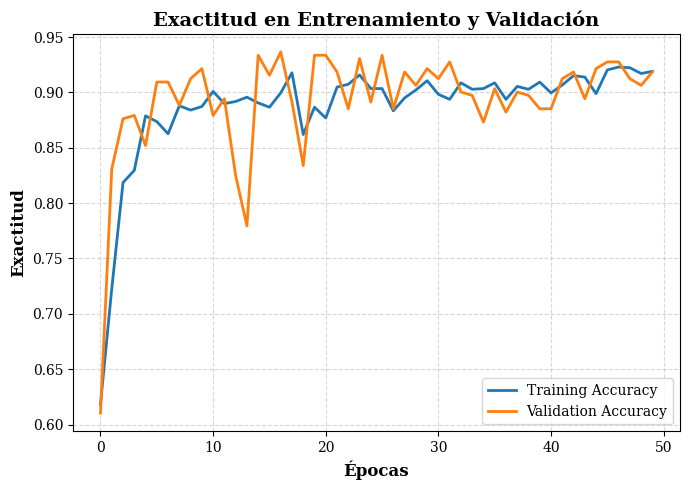

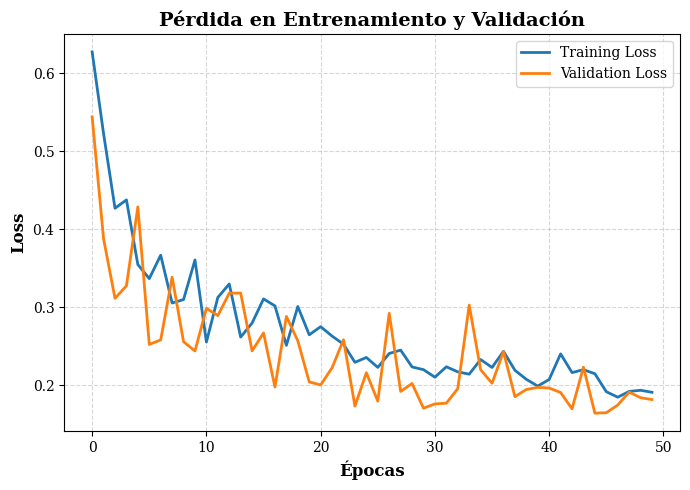

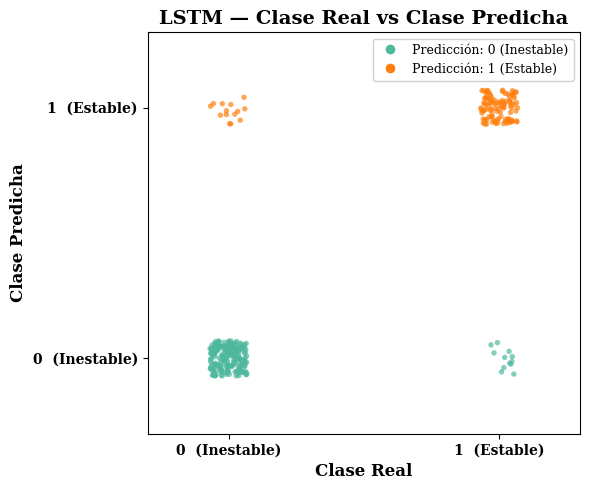

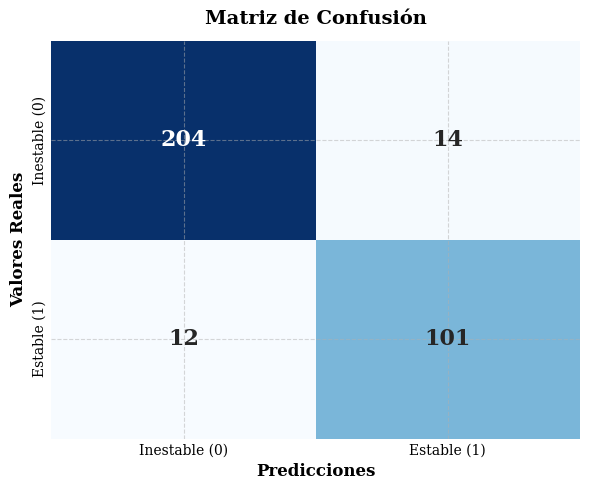

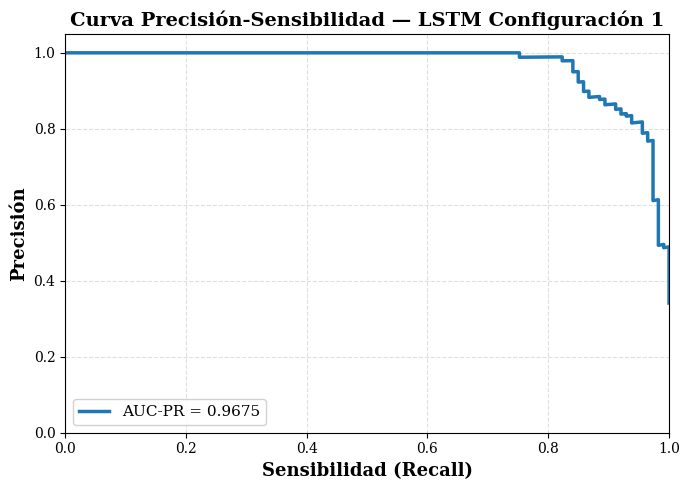

In [15]:
# ── Evaluación LSTM Exp. 1 (conjunto de validación) ───────────────────────────────────
predictions_lstm_1     = model_lstm_1.predict(x_val, verbose=0)
pred_labels_lstm_1     = (predictions_lstm_1 > 0.5).astype(int)

accuracy_lstm_1  = accuracy_score(y_val, pred_labels_lstm_1)
precision_lstm_1 = precision_score(y_val, pred_labels_lstm_1, zero_division=0)
recall_lstm_1    = recall_score(y_val, pred_labels_lstm_1, zero_division=0)
f1_lstm_1        = f1_score(y_val, pred_labels_lstm_1, zero_division=0)
cm_lstm_1        = confusion_matrix(y_val, pred_labels_lstm_1)
prec_curve_lstm_1, rec_curve_lstm_1, _ = precision_recall_curve(y_val, predictions_lstm_1.flatten())
auc_pr_lstm_1    = auc(rec_curve_lstm_1, prec_curve_lstm_1)

print(f'LSTM Exp 1 — Exactitud  (Accuracy):  {accuracy_lstm_1:.4f}')
print(f'LSTM Exp 1 — Precisión  (Precision): {precision_lstm_1:.4f}')
print(f'LSTM Exp 1 — Recall:                 {recall_lstm_1:.4f}')
print(f'LSTM Exp 1 — F1-Score:               {f1_lstm_1:.4f}')
print(f'LSTM Exp 1 — AUC-PR:                 {auc_pr_lstm_1:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_1.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_lstm_1.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_1.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_lstm_1.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_lstm_1.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_lstm_1))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_lstm_1.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'LSTM — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_lstm_1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_lstm_1, prec_curve_lstm_1,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_lstm_1:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — LSTM Configuración 1',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### LSTM — Configuración 2

Se agrega regularización L1 y L2 a las capas recurrentes para reducir 
el sobreajuste que se observó en la configuración anterior hacia las últimas épocas.


In [16]:
# ── Experimento 2 LSTM ───────────────────────────────────────────────────────
optimizer_lstm_2 = Adam(learning_rate=0.001)
model_lstm_2 = Sequential(name='lstm_exp2')
model_lstm_2.add(LSTM(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_lstm_2.add(Dropout(0.2))
model_lstm_2.add(LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_lstm_2.add(Dropout(0.2))
model_lstm_2.add(Dense(1, activation='sigmoid'))
model_lstm_2.compile(optimizer=optimizer_lstm_2,
                    loss='binary_crossentropy', metrics=['accuracy'])

callbacks_lstm_2 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  LSTM — Experimento 2  |  Dispositivo: {DEVICE}')
print(f'  lr=0.001 | épocas=50 | capas=2 | dropout=0.2 | L1=0.01 | L2=0.001')
print(f'{"="*55}')
history_lstm_2 = model_lstm_2.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_lstm_2,
    verbose=1
)

model_lstm_2.save(f'models/modelo_lstm_exp2.keras')
print(f'\nModelo guardado: models/modelo_lstm_exp2.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  LSTM — Experimento 2  |  Dispositivo: cuda
  lr=0.001 | épocas=50 | capas=2 | dropout=0.2 | L1=0.01 | L2=0.001
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 343ms/step - accuracy: 0.4503 - loss: 12.8993 - val_accuracy: 0.4381 - val_loss: 7.1496 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step - accuracy: 0.5381 - loss: 5.5865 - val_accuracy: 0.4381 - val_loss: 2.6112 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 301ms/step - accuracy: 0.4688 - loss: 1.9450 - val_accuracy: 0.5166 - val_loss: 1.0443 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.5356 - loss: 0.9597 - val_accuracy: 0.5015 - val_loss: 0.8668 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 343ms/step - accuracy: 0.5160 - loss: 0.9029 - val_accuracy: 0.4622 - val_loss: 0.8359 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 276ms/step - accuracy: 0.5228 - loss: 0.8174 - val_accuracy: 0.5468 - val_loss

LSTM Exp 2 — Exactitud  (Accuracy):  0.8912
LSTM Exp 2 — Precisión  (Precision): 0.8182
LSTM Exp 2 — Recall:                 0.8761
LSTM Exp 2 — F1-Score:               0.8462
LSTM Exp 2 — AUC-PR:                 0.7596


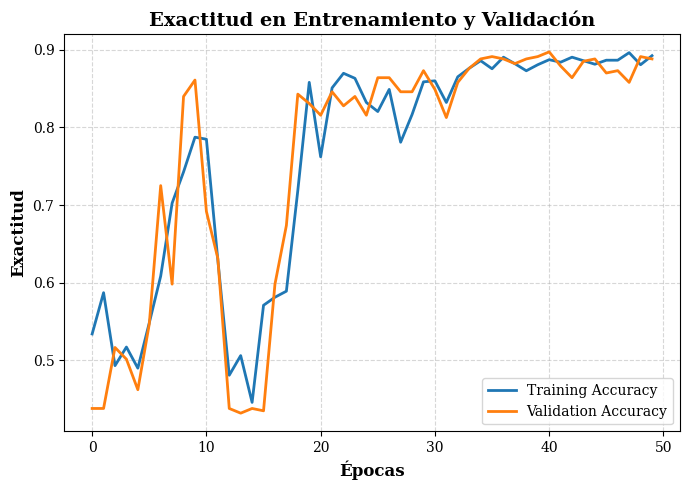

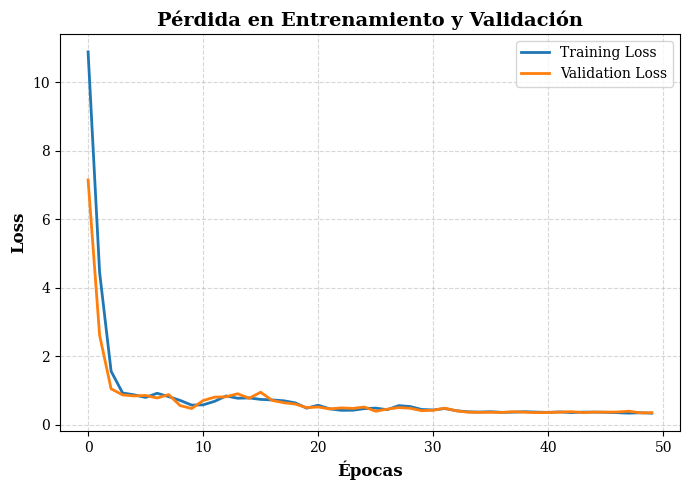

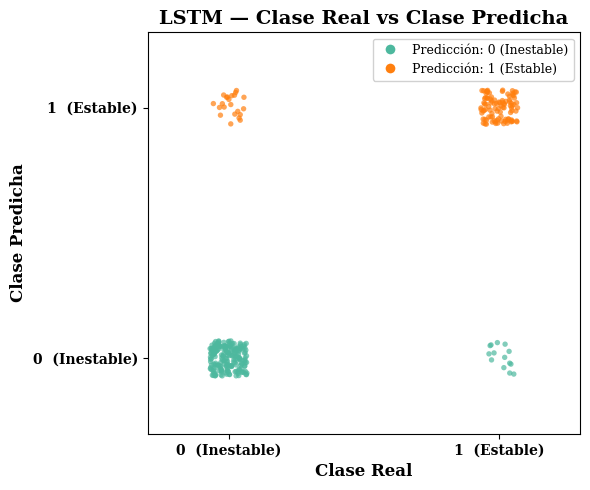

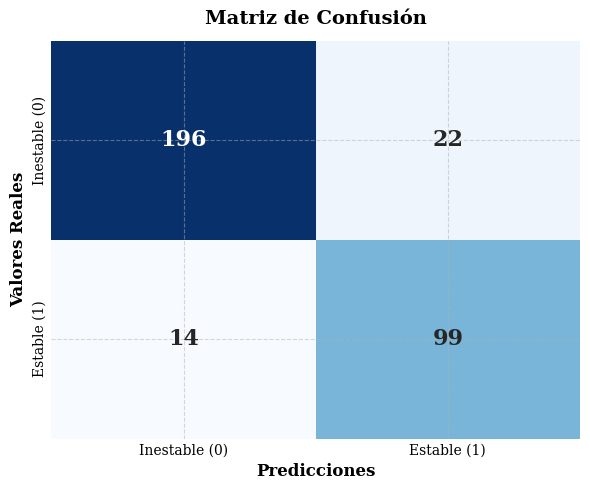

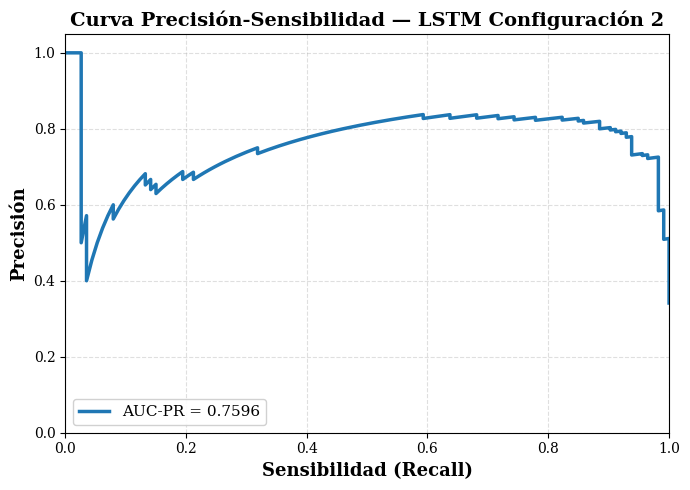

In [17]:
# ── Evaluación LSTM Exp. 2 (conjunto de validación) ───────────────────────────────────
predictions_lstm_2     = model_lstm_2.predict(x_val, verbose=0)
pred_labels_lstm_2     = (predictions_lstm_2 > 0.5).astype(int)

accuracy_lstm_2  = accuracy_score(y_val, pred_labels_lstm_2)
precision_lstm_2 = precision_score(y_val, pred_labels_lstm_2, zero_division=0)
recall_lstm_2    = recall_score(y_val, pred_labels_lstm_2, zero_division=0)
f1_lstm_2        = f1_score(y_val, pred_labels_lstm_2, zero_division=0)
cm_lstm_2        = confusion_matrix(y_val, pred_labels_lstm_2)
prec_curve_lstm_2, rec_curve_lstm_2, _ = precision_recall_curve(y_val, predictions_lstm_2.flatten())
auc_pr_lstm_2    = auc(rec_curve_lstm_2, prec_curve_lstm_2)

print(f'LSTM Exp 2 — Exactitud  (Accuracy):  {accuracy_lstm_2:.4f}')
print(f'LSTM Exp 2 — Precisión  (Precision): {precision_lstm_2:.4f}')
print(f'LSTM Exp 2 — Recall:                 {recall_lstm_2:.4f}')
print(f'LSTM Exp 2 — F1-Score:               {f1_lstm_2:.4f}')
print(f'LSTM Exp 2 — AUC-PR:                 {auc_pr_lstm_2:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_2.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_lstm_2.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_2.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_lstm_2.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_lstm_2.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_lstm_2))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_lstm_2.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'LSTM — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_lstm_2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_lstm_2, prec_curve_lstm_2,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_lstm_2:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — LSTM Configuración 2',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### LSTM — Configuración 3

Se aumenta la profundidad de la red a 3 capas y se incrementa el dropout 
para mejorar la capacidad de generalización en una arquitectura más compleja.


In [18]:
# ── Experimento 3 LSTM ───────────────────────────────────────────────────────
optimizer_lstm_3 = Adam(learning_rate=0.0015)
model_lstm_3 = Sequential(name='lstm_exp3')
model_lstm_3.add(LSTM(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_lstm_3.add(Dropout(0.3))
model_lstm_3.add(LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_lstm_3.add(Dropout(0.3))
model_lstm_3.add(LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_lstm_3.add(Dropout(0.3))
model_lstm_3.add(Dense(32, activation='relu'))
model_lstm_3.add(Dense(1, activation='sigmoid'))
model_lstm_3.compile(optimizer=optimizer_lstm_3,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_lstm_3 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  LSTM — Experimento 3  |  Dispositivo: {DEVICE}')
print(f'  lr=0.0015 | épocas=50 | capas=3 | dropout=0.3 | L1=0.01 | L2=0.001')
print(f'{"="*55}')
history_lstm_3 = model_lstm_3.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_lstm_3,
    verbose=1
)

model_lstm_3.save(f'models/modelo_lstm_exp3.keras')
print(f'\nModelo guardado: models/modelo_lstm_exp3.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  LSTM — Experimento 3  |  Dispositivo: cuda
  lr=0.0015 | épocas=50 | capas=3 | dropout=0.3 | L1=0.01 | L2=0.001
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 0.5306 - loss: 20.6825 - val_accuracy: 0.4381 - val_loss: 7.1347 - learning_rate: 0.0015
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 372ms/step - accuracy: 0.4544 - loss: 4.7872 - val_accuracy: 0.4864 - val_loss: 1.2510 - learning_rate: 0.0015
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 336ms/step - accuracy: 0.5191 - loss: 1.1281 - val_accuracy: 0.8520 - val_loss: 0.8045 - learning_rate: 0.0015
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - accuracy: 0.7022 - loss: 0.8608 - val_accuracy: 0.4381 - val_loss: 1.0101 - learning_rate: 0.0015
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 459ms/step - accuracy: 0.5128 - loss: 0.9140 - val_accuracy: 0.7432 - val_loss: 0.7312 - learning_rate: 0.0015
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 457ms/step - accuracy: 0.6425 - loss: 0.8052 - val_accuracy: 0.7130 - val_los

LSTM Exp 3 — Exactitud  (Accuracy):  0.8731
LSTM Exp 3 — Precisión  (Precision): 0.7591
LSTM Exp 3 — Recall:                 0.9204
LSTM Exp 3 — F1-Score:               0.8320
LSTM Exp 3 — AUC-PR:                 0.7722


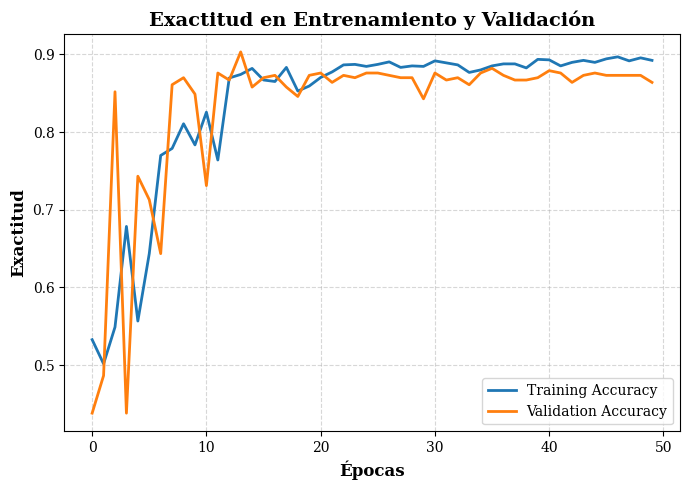

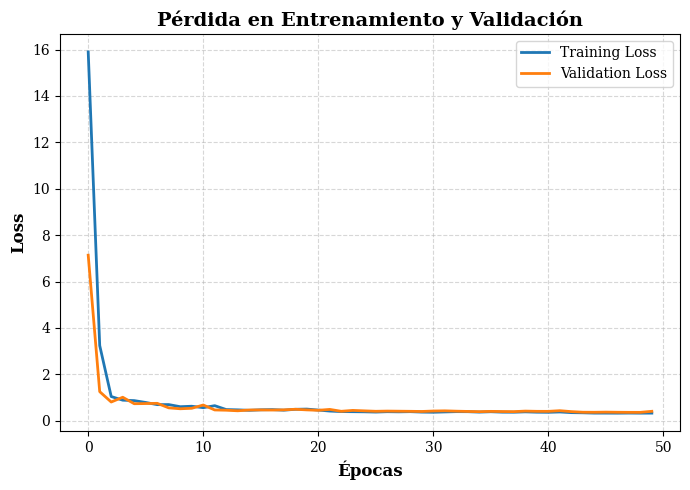

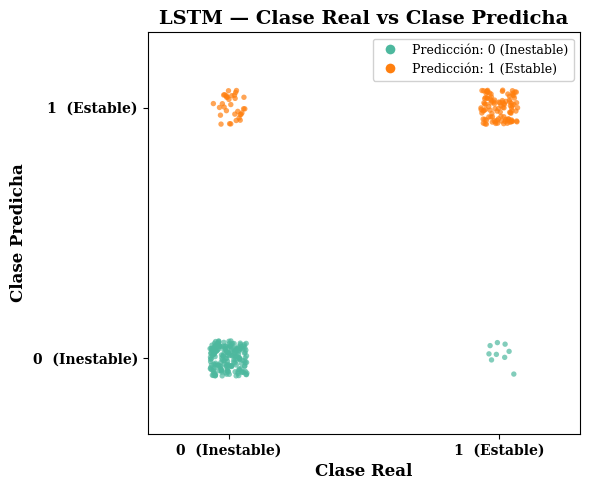

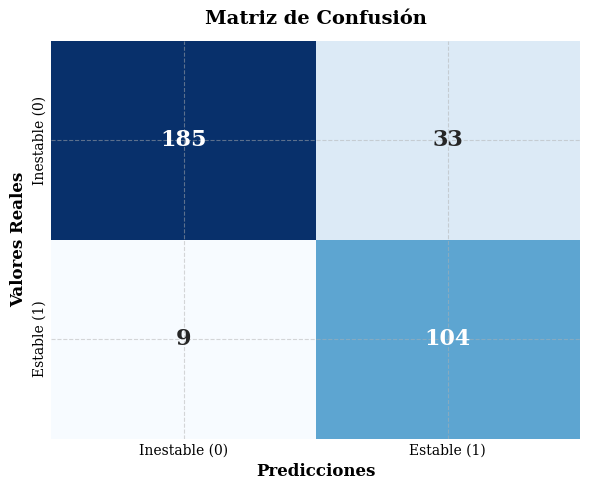

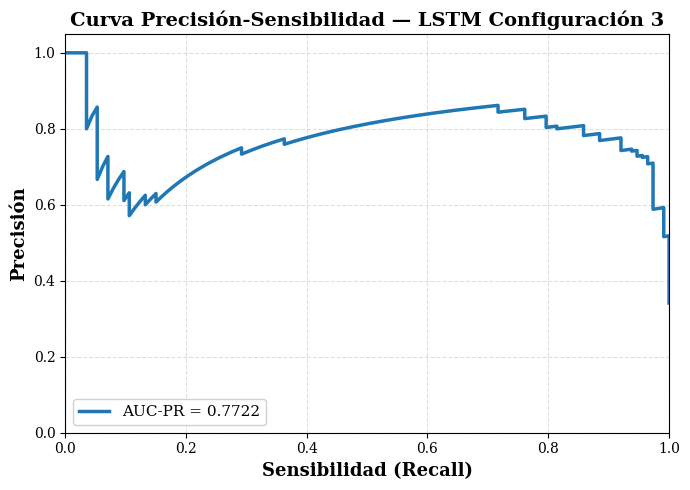

In [19]:
# ── Evaluación LSTM Exp. 3 (conjunto de validación) ───────────────────────────────────
predictions_lstm_3     = model_lstm_3.predict(x_val, verbose=0)
pred_labels_lstm_3     = (predictions_lstm_3 > 0.5).astype(int)

accuracy_lstm_3  = accuracy_score(y_val, pred_labels_lstm_3)
precision_lstm_3 = precision_score(y_val, pred_labels_lstm_3, zero_division=0)
recall_lstm_3    = recall_score(y_val, pred_labels_lstm_3, zero_division=0)
f1_lstm_3        = f1_score(y_val, pred_labels_lstm_3, zero_division=0)
cm_lstm_3        = confusion_matrix(y_val, pred_labels_lstm_3)
prec_curve_lstm_3, rec_curve_lstm_3, _ = precision_recall_curve(y_val, predictions_lstm_3.flatten())
auc_pr_lstm_3    = auc(rec_curve_lstm_3, prec_curve_lstm_3)

print(f'LSTM Exp 3 — Exactitud  (Accuracy):  {accuracy_lstm_3:.4f}')
print(f'LSTM Exp 3 — Precisión  (Precision): {precision_lstm_3:.4f}')
print(f'LSTM Exp 3 — Recall:                 {recall_lstm_3:.4f}')
print(f'LSTM Exp 3 — F1-Score:               {f1_lstm_3:.4f}')
print(f'LSTM Exp 3 — AUC-PR:                 {auc_pr_lstm_3:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_3.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_lstm_3.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_3.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_lstm_3.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_lstm_3.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_lstm_3))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_lstm_3.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'LSTM — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_lstm_3, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_lstm_3, prec_curve_lstm_3,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_lstm_3:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — LSTM Configuración 3',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### LSTM — Configuración 4

Se extiende el número de épocas a 100 para permitir que la red más profunda 
converja adecuadamente, manteniendo la regularización L1 para controlar el sobreajuste.


In [20]:
# ── Experimento 4 LSTM ───────────────────────────────────────────────────────
optimizer_lstm_4 = Adam(learning_rate=0.0015)
model_lstm_4 = Sequential(name='lstm_exp4')
model_lstm_4.add(LSTM(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l1(0.01)))
model_lstm_4.add(Dropout(0.25))
model_lstm_4.add(LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l1(0.01)))
model_lstm_4.add(Dropout(0.25))
model_lstm_4.add(LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l1(0.01)))
model_lstm_4.add(Dropout(0.25))
model_lstm_4.add(Dense(32, activation='relu'))
model_lstm_4.add(Dense(1, activation='sigmoid'))
model_lstm_4.compile(optimizer=optimizer_lstm_4,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_lstm_4 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  LSTM — Experimento 4  |  Dispositivo: {DEVICE}')
print(f'  lr=0.0015 | épocas=100 | capas=3 | dropout=0.25 | L1=0.01 | L2=0')
print(f'{"="*55}')
history_lstm_4 = model_lstm_4.fit(
    x_train, y_train,
    epochs=100,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_lstm_4,
    verbose=1
)

model_lstm_4.save(f'models/modelo_lstm_exp4.keras')
print(f'\nModelo guardado: models/modelo_lstm_exp4.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  LSTM — Experimento 4  |  Dispositivo: cuda
  lr=0.0015 | épocas=100 | capas=3 | dropout=0.25 | L1=0.01 | L2=0
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 534ms/step - accuracy: 0.5256 - loss: 20.4736 - val_accuracy: 0.6163 - val_loss: 6.9063 - learning_rate: 0.0015
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 444ms/step - accuracy: 0.5235 - loss: 4.5781 - val_accuracy: 0.3414 - val_loss: 1.3670 - learning_rate: 0.0015
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 309ms/step - accuracy: 0.4759 - loss: 1.1572 - val_accuracy: 0.6586 - val_loss: 0.9022 - learning_rate: 0.0015
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 332ms/step - accuracy: 0.4504 - loss: 0.8842 - val_accuracy: 0.3414 - val_loss: 0.8400 - learning_rate: 0.0015
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 477ms/step - accuracy: 0.6037 - loss: 0.8252 - val_accuracy: 0.3414 - val_loss: 0.8125 - learning_rate: 0.0015
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 416ms/step - accuracy: 0.4124 - loss: 0.8122 - val_accuracy: 0.3414 - val

LSTM Exp 4 — Exactitud  (Accuracy):  0.3414
LSTM Exp 4 — Precisión  (Precision): 0.3414
LSTM Exp 4 — Recall:                 1.0000
LSTM Exp 4 — F1-Score:               0.5090
LSTM Exp 4 — AUC-PR:                 0.6676


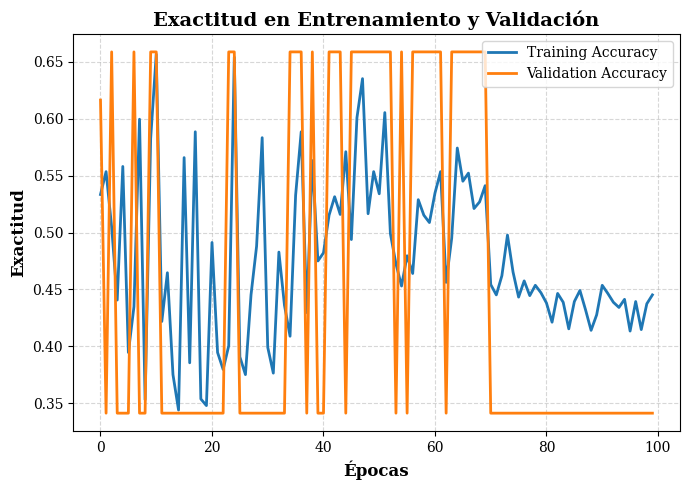

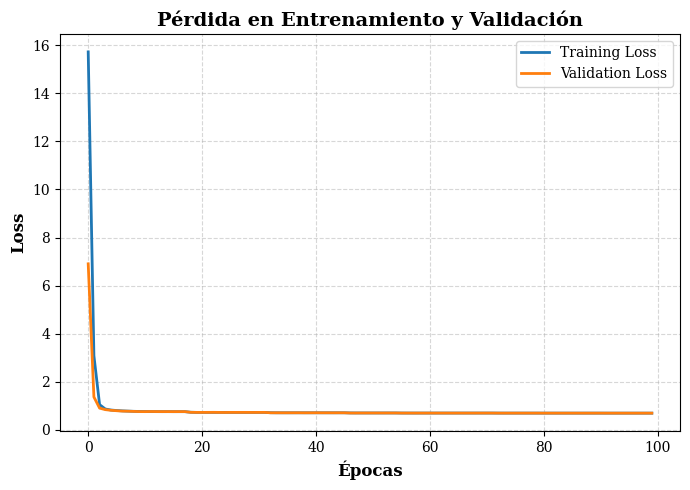

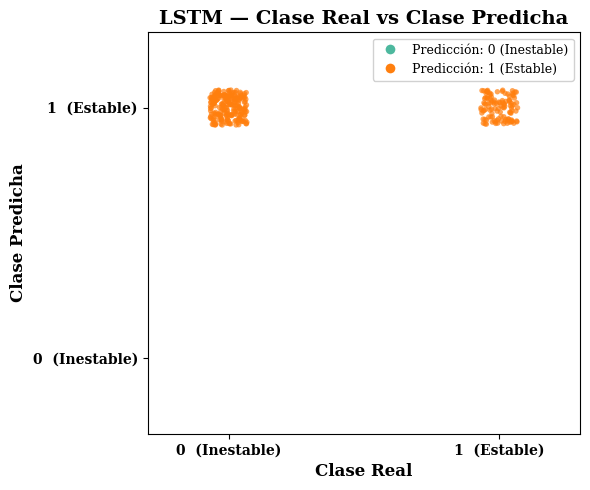

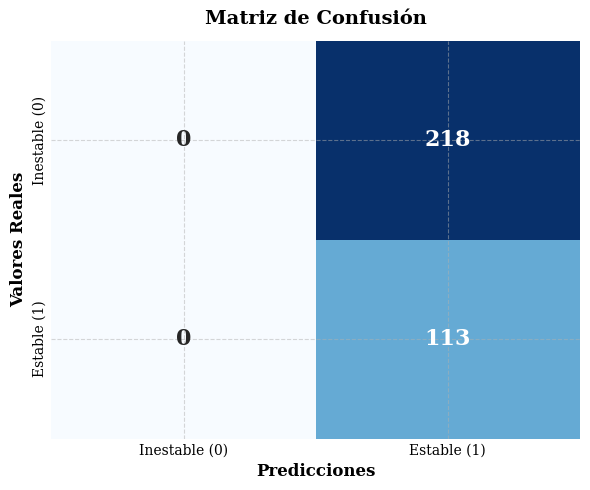

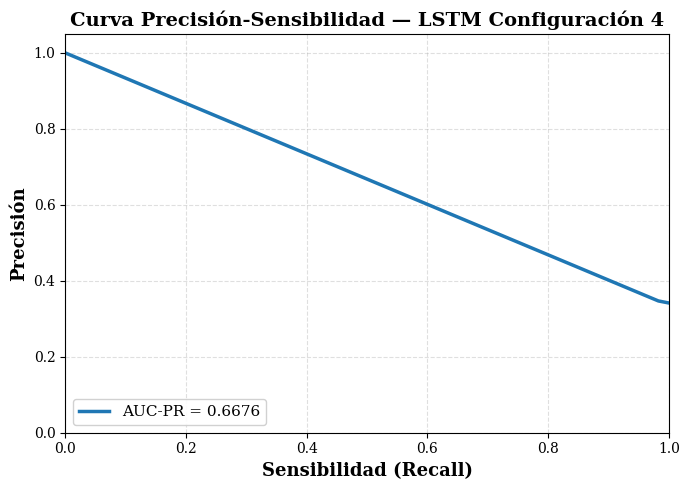

In [21]:
# ── Evaluación LSTM Exp. 4 (conjunto de validación) ───────────────────────────────────
predictions_lstm_4     = model_lstm_4.predict(x_val, verbose=0)
pred_labels_lstm_4     = (predictions_lstm_4 > 0.5).astype(int)

accuracy_lstm_4  = accuracy_score(y_val, pred_labels_lstm_4)
precision_lstm_4 = precision_score(y_val, pred_labels_lstm_4, zero_division=0)
recall_lstm_4    = recall_score(y_val, pred_labels_lstm_4, zero_division=0)
f1_lstm_4        = f1_score(y_val, pred_labels_lstm_4, zero_division=0)
cm_lstm_4        = confusion_matrix(y_val, pred_labels_lstm_4)
prec_curve_lstm_4, rec_curve_lstm_4, _ = precision_recall_curve(y_val, predictions_lstm_4.flatten())
auc_pr_lstm_4    = auc(rec_curve_lstm_4, prec_curve_lstm_4)

print(f'LSTM Exp 4 — Exactitud  (Accuracy):  {accuracy_lstm_4:.4f}')
print(f'LSTM Exp 4 — Precisión  (Precision): {precision_lstm_4:.4f}')
print(f'LSTM Exp 4 — Recall:                 {recall_lstm_4:.4f}')
print(f'LSTM Exp 4 — F1-Score:               {f1_lstm_4:.4f}')
print(f'LSTM Exp 4 — AUC-PR:                 {auc_pr_lstm_4:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_4.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_lstm_4.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_4.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_lstm_4.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_lstm_4.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_lstm_4))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_lstm_4.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'LSTM — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_lstm_4, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_lstm_4, prec_curve_lstm_4,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_lstm_4:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — LSTM Configuración 4',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### LSTM — Configuración 5

Se usa una tasa de aprendizaje muy baja con regularización L2 solamente, 
buscando una convergencia más suave en una red de 3 capas. 
El número de épocas es 100 para compensar el aprendizaje más lento.


In [22]:
# ── Experimento 5 LSTM ───────────────────────────────────────────────────────
optimizer_lstm_5 = Adam(learning_rate=0.0001)
model_lstm_5 = Sequential(name='lstm_exp5')
model_lstm_5.add(LSTM(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l2(0.001)))
model_lstm_5.add(Dropout(0.15))
model_lstm_5.add(LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(0.001)))
model_lstm_5.add(Dropout(0.15))
model_lstm_5.add(LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
model_lstm_5.add(Dropout(0.15))
model_lstm_5.add(Dense(32, activation='relu'))
model_lstm_5.add(Dense(1, activation='sigmoid'))
model_lstm_5.compile(optimizer=optimizer_lstm_5,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_lstm_5 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  LSTM — Experimento 5  |  Dispositivo: {DEVICE}')
print(f'  lr=0.0001 | épocas=100 | capas=3 | dropout=0.15 | L1=0 | L2=0.001')
print(f'{"="*55}')
history_lstm_5 = model_lstm_5.fit(
    x_train, y_train,
    epochs=100,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_lstm_5,
    verbose=1
)

model_lstm_5.save(f'models/modelo_lstm_exp5.keras')
print(f'\nModelo guardado: models/modelo_lstm_exp5.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  LSTM — Experimento 5  |  Dispositivo: cuda
  lr=0.0001 | épocas=100 | capas=3 | dropout=0.15 | L1=0 | L2=0.001
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 360ms/step - accuracy: 0.6138 - loss: 0.9201 - val_accuracy: 0.6284 - val_loss: 0.8868 - learning_rate: 1.0000e-04
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 369ms/step - accuracy: 0.6181 - loss: 0.8601 - val_accuracy: 0.6314 - val_loss: 0.7957 - learning_rate: 1.0000e-04
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 316ms/step - accuracy: 0.6616 - loss: 0.7666 - val_accuracy: 0.6465 - val_loss: 0.7698 - learning_rate: 1.0000e-04
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 312ms/step - accuracy: 0.6780 - loss: 0.7758 - val_accuracy: 0.6284 - val_loss: 0.7535 - learning_rate: 1.0000e-04
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 346ms/step - accuracy: 0.6643 - loss: 0.7388 - val_accuracy: 0.8580 - val_loss: 0.5931 - learning_rate: 1.0000e-04
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 390ms/step - accuracy: 0.8308 - loss: 0.6291 - val_ac

LSTM Exp 5 — Exactitud  (Accuracy):  0.9245
LSTM Exp 5 — Precisión  (Precision): 0.9314
LSTM Exp 5 — Recall:                 0.8407
LSTM Exp 5 — F1-Score:               0.8837
LSTM Exp 5 — AUC-PR:                 0.9685


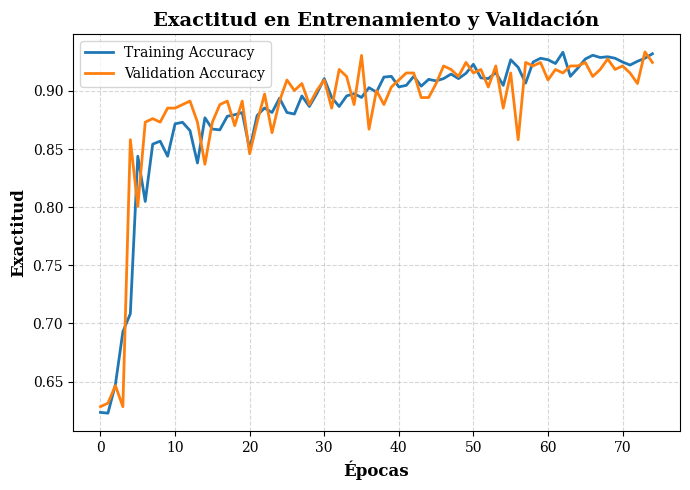

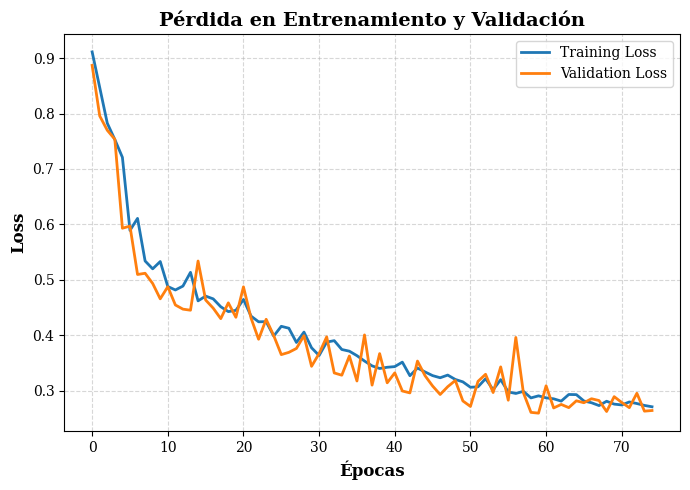

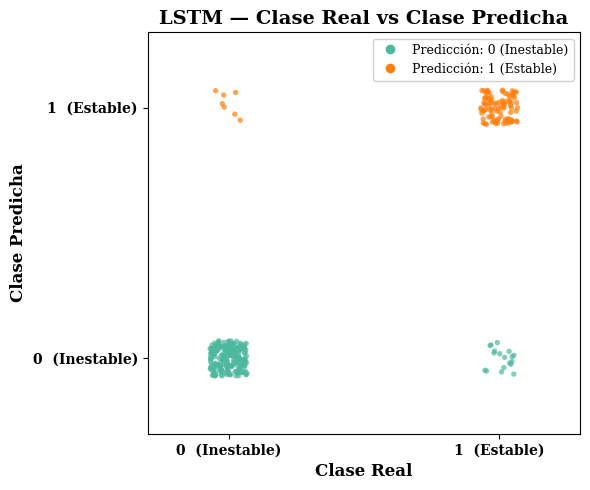

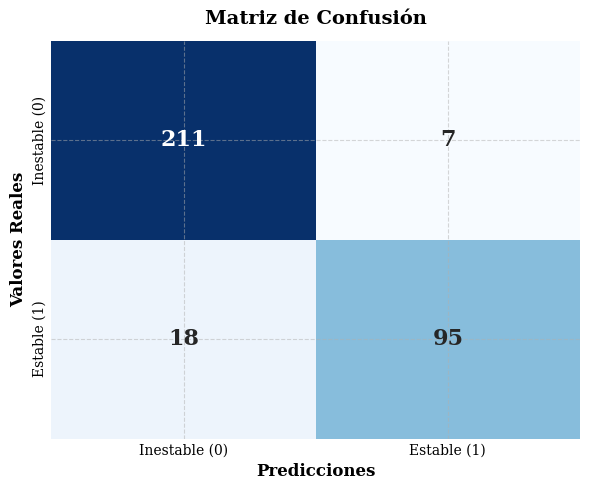

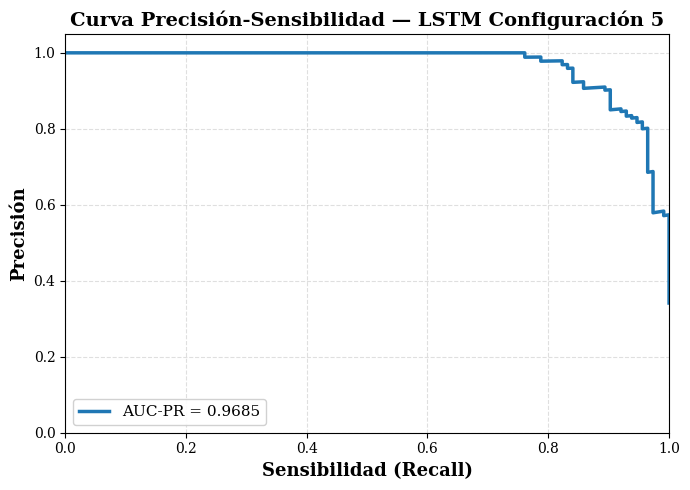

In [23]:
# ── Evaluación LSTM Exp. 5 (conjunto de validación) ───────────────────────────────────
predictions_lstm_5     = model_lstm_5.predict(x_val, verbose=0)
pred_labels_lstm_5     = (predictions_lstm_5 > 0.5).astype(int)

accuracy_lstm_5  = accuracy_score(y_val, pred_labels_lstm_5)
precision_lstm_5 = precision_score(y_val, pred_labels_lstm_5, zero_division=0)
recall_lstm_5    = recall_score(y_val, pred_labels_lstm_5, zero_division=0)
f1_lstm_5        = f1_score(y_val, pred_labels_lstm_5, zero_division=0)
cm_lstm_5        = confusion_matrix(y_val, pred_labels_lstm_5)
prec_curve_lstm_5, rec_curve_lstm_5, _ = precision_recall_curve(y_val, predictions_lstm_5.flatten())
auc_pr_lstm_5    = auc(rec_curve_lstm_5, prec_curve_lstm_5)

print(f'LSTM Exp 5 — Exactitud  (Accuracy):  {accuracy_lstm_5:.4f}')
print(f'LSTM Exp 5 — Precisión  (Precision): {precision_lstm_5:.4f}')
print(f'LSTM Exp 5 — Recall:                 {recall_lstm_5:.4f}')
print(f'LSTM Exp 5 — F1-Score:               {f1_lstm_5:.4f}')
print(f'LSTM Exp 5 — AUC-PR:                 {auc_pr_lstm_5:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_5.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_lstm_5.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_lstm_5.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_lstm_5.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_lstm_5.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_lstm_5))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_lstm_5.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'LSTM — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_lstm_5, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_lstm_5, prec_curve_lstm_5,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_lstm_5:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — LSTM Configuración 5',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

## Curvas Precisión-Sensibilidad — comparativa LSTM

Las curvas Precisión-Sensibilidad (*Precision-Recall*) son más informativas que la curva ROC 
cuando existe desbalance de clases, ya que se enfocan en el rendimiento 
sobre la clase minoritaria.

El **AUC-PR** (área bajo la curva) resume en un único valor la capacidad 
del modelo para distinguir correctamente entre clases. 
Un valor de AUC-PR = 1.0 indica clasificación perfecta.


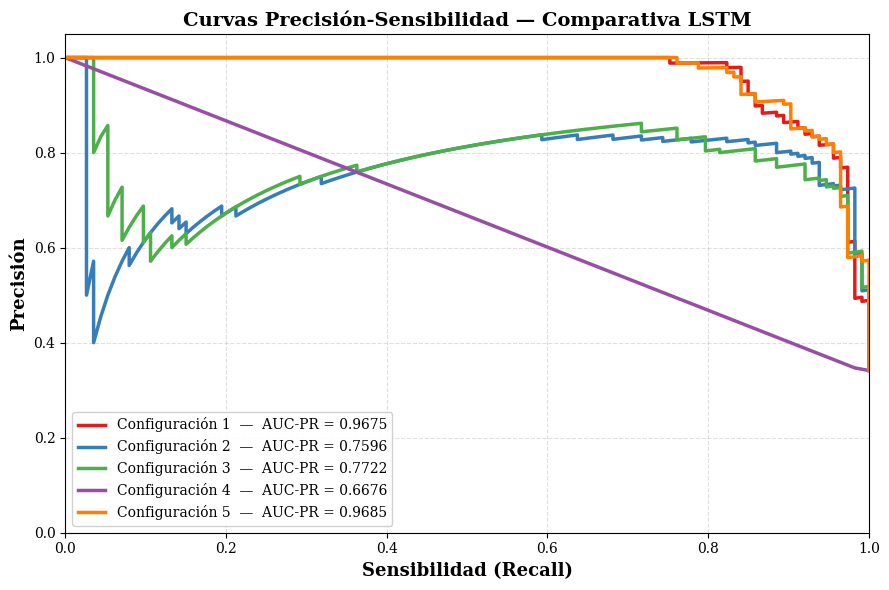


LSTM — AUC-PR (conjunto de validación):
  Configuración 1: 0.9675
  Configuración 2: 0.7596
  Configuración 3: 0.7722
  Configuración 4: 0.6676
  Configuración 5: 0.9685


In [24]:
# ── Curva Precisión-Sensibilidad comparativa — LSTM ───────────────────────────────────
plt.figure(figsize=(9, 6))
plt.plot(rec_curve_lstm_1, prec_curve_lstm_1, lw=2.5, color='#e41a1c',
         label=f'Configuración 1  —  AUC-PR = {auc_pr_lstm_1:.4f}')
plt.plot(rec_curve_lstm_2, prec_curve_lstm_2, lw=2.5, color='#377eb8',
         label=f'Configuración 2  —  AUC-PR = {auc_pr_lstm_2:.4f}')
plt.plot(rec_curve_lstm_3, prec_curve_lstm_3, lw=2.5, color='#4daf4a',
         label=f'Configuración 3  —  AUC-PR = {auc_pr_lstm_3:.4f}')
plt.plot(rec_curve_lstm_4, prec_curve_lstm_4, lw=2.5, color='#984ea3',
         label=f'Configuración 4  —  AUC-PR = {auc_pr_lstm_4:.4f}')
plt.plot(rec_curve_lstm_5, prec_curve_lstm_5, lw=2.5, color='#ff7f00',
         label=f'Configuración 5  —  AUC-PR = {auc_pr_lstm_5:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curvas Precisión-Sensibilidad — Comparativa LSTM',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

print('\nLSTM — AUC-PR (conjunto de validación):')
for _i in range(1, 6):
    print(f'  Configuración {_i}: {globals()["auc_pr_lstm_" + str(_i)]:.4f}')

---

# Modelos GRU

Las redes GRU (*Gated Recurrent Unit*) son una simplificación de las LSTM 
que combinan las compuertas de entrada y olvido en una sola compuerta de actualización. 
Esto las hace computacionalmente más eficientes mientras mantienen 
una capacidad similar para capturar dependencias temporales.

## Flujo de implementación

```
Remuestreo de la data           Entrenamiento del modelo GRU
(según su frecuencia)                        ↓
        ↓                        Métricas de rendimiento
Creación del conjunto              (conjunto de validación — 15%)
de entrada y salida                          ↓
(x: tensor 3D, y: 1D)           Gráficas de rendimiento
        ↓                          (Exactitud y Pérdida)
División de los datos                        ↓
  70% entrenamiento               Gráfica de predicciones
  15% validación                    (Real vs Predicción)
  15% backtesting (datos no vistos)          ↓
        ↓                          Matriz de confusión
Creación de la red GRU
(capas recurrentes, dropout, densa)
```

## Configuraciones evaluadas

Se entrenaron 5 configuraciones equivalentes a las del LSTM, 
ajustando los valores de dropout considerando que GRU tiende a 
requerir mayor regularización estocástica para no sobreajustarse.


### GRU — Configuración 1

Configuración base sin regularización. 
El dropout de 0.5 es mayor que en el LSTM equivalente, 
lo que refleja la menor capacidad intrínseca de regularización de la arquitectura GRU.


In [25]:
# ── Experimento 1 GRU ───────────────────────────────────────────────────────
optimizer_gru_1 = Adam(learning_rate=0.001)
model_gru_1 = Sequential(name='gru_exp1')
model_gru_1.add(GRU(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2])))
model_gru_1.add(Dropout(0.5))
model_gru_1.add(GRU(64, return_sequences=False))
model_gru_1.add(Dropout(0.5))
model_gru_1.add(Dense(1, activation='sigmoid'))
model_gru_1.compile(optimizer=optimizer_gru_1,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_gru_1 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  GRU — Experimento 1  |  Dispositivo: {DEVICE}')
print(f'  lr=0.001 | épocas=50 | capas=2 | dropout=0.5 | L1=0 | L2=0')
print(f'{"="*55}')
history_gru_1 = model_gru_1.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_gru_1,
    verbose=1
)

model_gru_1.save(f'models/modelo_gru_exp1.keras')
print(f'\nModelo guardado: models/modelo_gru_exp1.keras')


  GRU — Experimento 1  |  Dispositivo: cuda
  lr=0.001 | épocas=50 | capas=2 | dropout=0.5 | L1=0 | L2=0


c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.5341 - loss: 0.6878 - val_accuracy: 0.6888 - val_loss: 0.5760 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.6335 - loss: 0.5875 - val_accuracy: 0.6344 - val_loss: 0.6131 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.6298 - loss: 0.5804 - val_accuracy: 0.6405 - val_loss: 0.5908 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.6788 - loss: 0.5656 - val_accuracy: 0.6707 - val_loss: 0.5133 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.6717 - loss: 0.5539 - val_accuracy: 0.7492 - val_loss: 0.4637 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.7973 - loss: 0.4393 - val_accuracy: 0.8671 - val_loss: 0.3359 - learning_rate: 0.0010
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.8497 - loss: 0.3813 

GRU Exp 1 — Exactitud  (Accuracy):  0.9366
GRU Exp 1 — Precisión  (Precision): 0.8966
GRU Exp 1 — Recall:                 0.9204
GRU Exp 1 — F1-Score:               0.9083
GRU Exp 1 — AUC-PR:                 0.9752


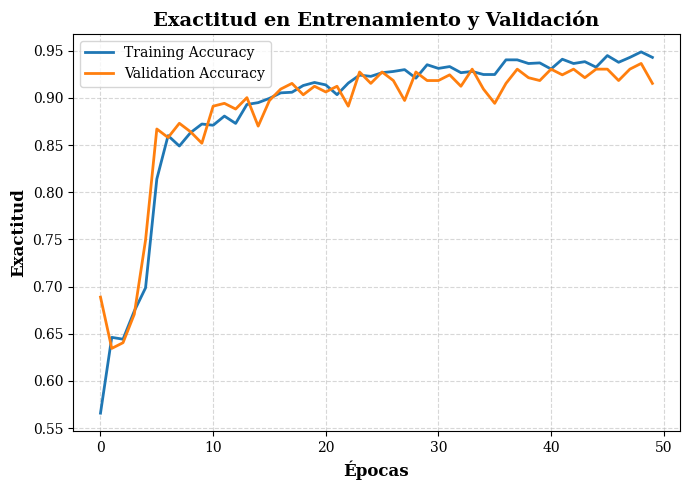

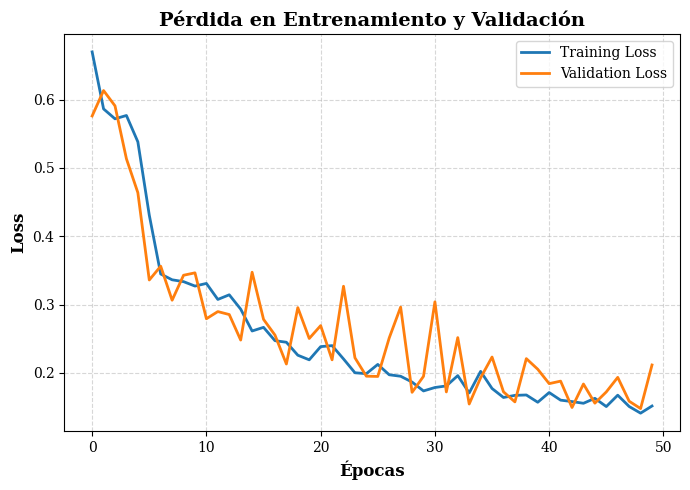

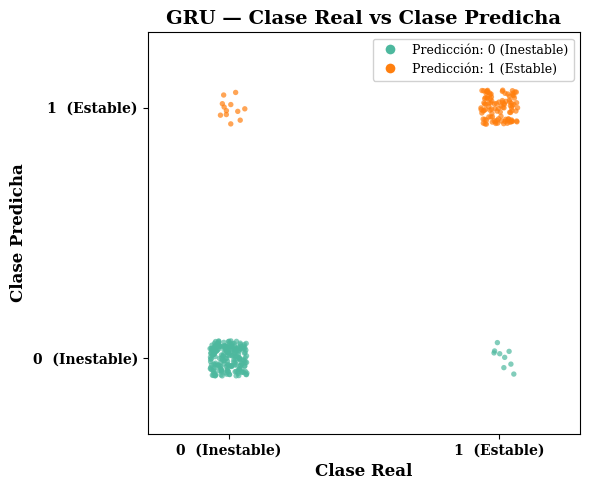

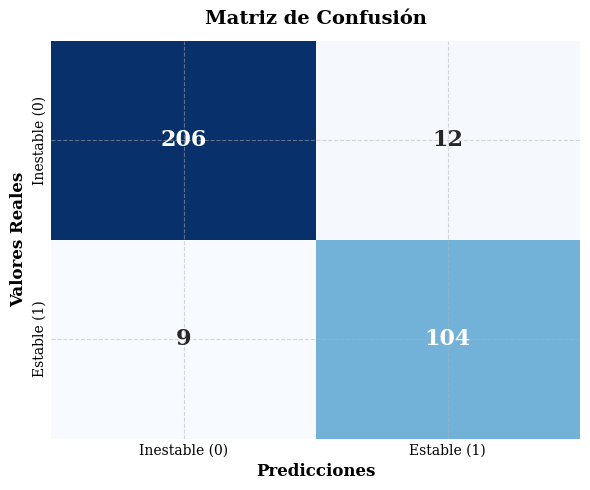

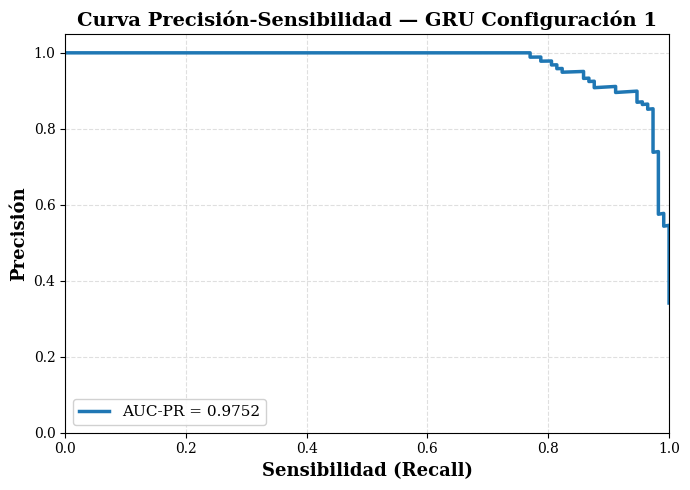

In [26]:
# ── Evaluación GRU Exp. 1 (conjunto de validación) ───────────────────────────────────
predictions_gru_1     = model_gru_1.predict(x_val, verbose=0)
pred_labels_gru_1     = (predictions_gru_1 > 0.5).astype(int)

accuracy_gru_1  = accuracy_score(y_val, pred_labels_gru_1)
precision_gru_1 = precision_score(y_val, pred_labels_gru_1, zero_division=0)
recall_gru_1    = recall_score(y_val, pred_labels_gru_1, zero_division=0)
f1_gru_1        = f1_score(y_val, pred_labels_gru_1, zero_division=0)
cm_gru_1        = confusion_matrix(y_val, pred_labels_gru_1)
prec_curve_gru_1, rec_curve_gru_1, _ = precision_recall_curve(y_val, predictions_gru_1.flatten())
auc_pr_gru_1    = auc(rec_curve_gru_1, prec_curve_gru_1)

print(f'GRU Exp 1 — Exactitud  (Accuracy):  {accuracy_gru_1:.4f}')
print(f'GRU Exp 1 — Precisión  (Precision): {precision_gru_1:.4f}')
print(f'GRU Exp 1 — Recall:                 {recall_gru_1:.4f}')
print(f'GRU Exp 1 — F1-Score:               {f1_gru_1:.4f}')
print(f'GRU Exp 1 — AUC-PR:                 {auc_pr_gru_1:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_1.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_gru_1.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_1.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_gru_1.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_gru_1.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_gru_1))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_gru_1.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'GRU — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_gru_1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_gru_1, prec_curve_gru_1,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_gru_1:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — GRU Configuración 1',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### GRU — Configuración 2

Se agrega regularización L1 y L2. El dropout se mantiene en 0.5 
para evitar sobreajuste en una red con mayor penalización sobre los pesos.


In [27]:
# ── Experimento 2 GRU ───────────────────────────────────────────────────────
optimizer_gru_2 = Adam(learning_rate=0.001)
model_gru_2 = Sequential(name='gru_exp2')
model_gru_2.add(GRU(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_gru_2.add(Dropout(0.5))
model_gru_2.add(GRU(64, return_sequences=False, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_gru_2.add(Dropout(0.5))
model_gru_2.add(Dense(1, activation='sigmoid'))
model_gru_2.compile(optimizer=optimizer_gru_2,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_gru_2 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  GRU — Experimento 2  |  Dispositivo: {DEVICE}')
print(f'  lr=0.001 | épocas=50 | capas=2 | dropout=0.5 | L1=0.01 | L2=0.001')
print(f'{"="*55}')
history_gru_2 = model_gru_2.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_gru_2,
    verbose=1
)

model_gru_2.save(f'models/modelo_gru_exp2.keras')
print(f'\nModelo guardado: models/modelo_gru_exp2.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  GRU — Experimento 2  |  Dispositivo: cuda
  lr=0.001 | épocas=50 | capas=2 | dropout=0.5 | L1=0.01 | L2=0.001
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.5691 - loss: 11.0390 - val_accuracy: 0.6314 - val_loss: 6.5469 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.5103 - loss: 5.4277 - val_accuracy: 0.6405 - val_loss: 2.6326 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.6262 - loss: 2.0374 - val_accuracy: 0.6979 - val_loss: 0.8401 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.6332 - loss: 0.9016 - val_accuracy: 0.7825 - val_loss: 0.6595 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.6503 - loss: 0.8166 - val_accuracy: 0.4109 - val_loss: 0.8380 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.5933 - loss: 0.8261 - val_accuracy: 0.4381 - val_loss: 0

GRU Exp 2 — Exactitud  (Accuracy):  0.9003
GRU Exp 2 — Precisión  (Precision): 0.8030
GRU Exp 2 — Recall:                 0.9381
GRU Exp 2 — F1-Score:               0.8653
GRU Exp 2 — AUC-PR:                 0.7584


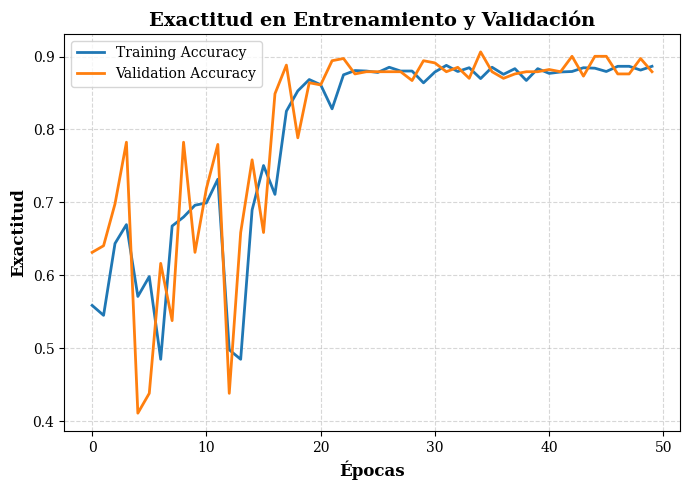

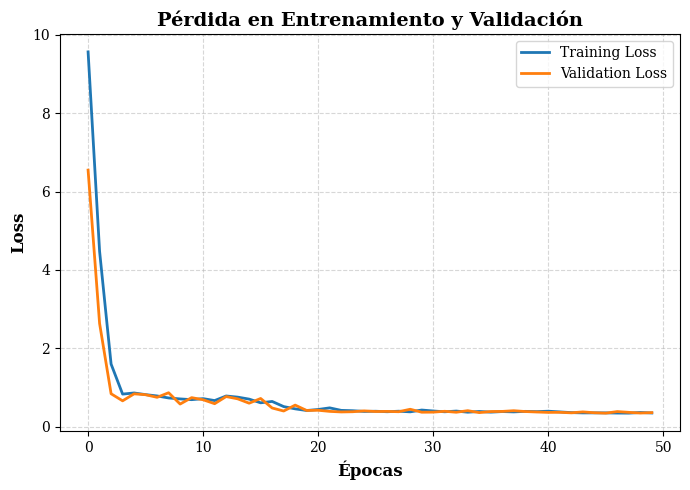

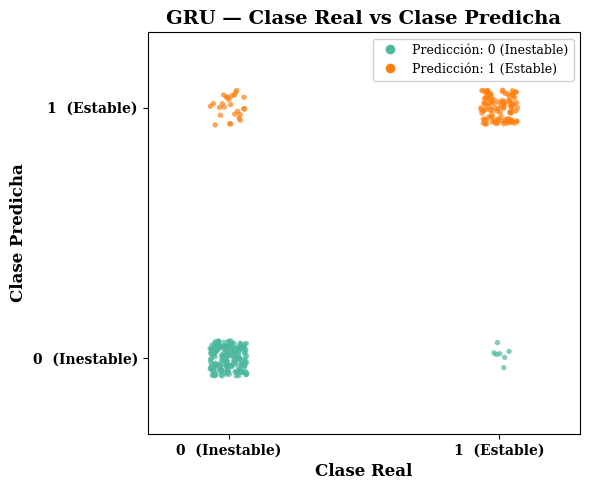

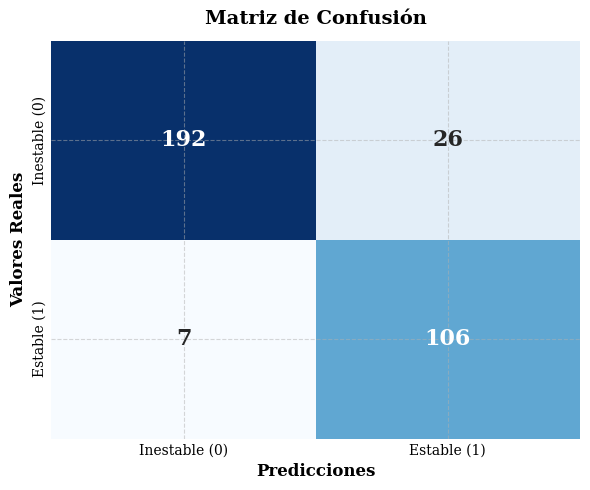

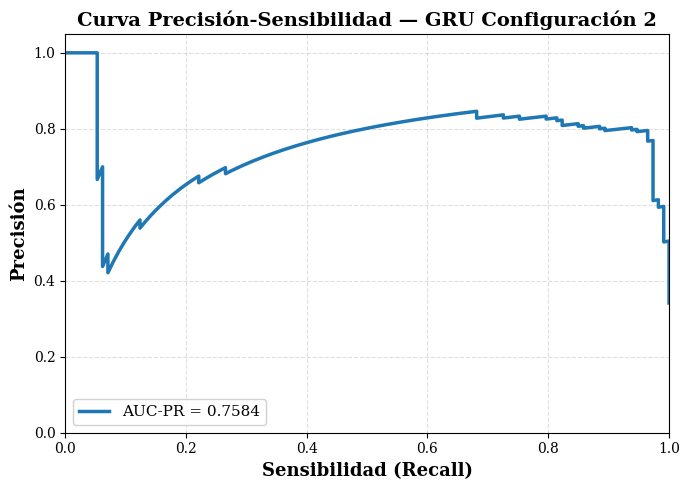

In [28]:
# ── Evaluación GRU Exp. 2 (conjunto de validación) ───────────────────────────────────
predictions_gru_2     = model_gru_2.predict(x_val, verbose=0)
pred_labels_gru_2     = (predictions_gru_2 > 0.5).astype(int)

accuracy_gru_2  = accuracy_score(y_val, pred_labels_gru_2)
precision_gru_2 = precision_score(y_val, pred_labels_gru_2, zero_division=0)
recall_gru_2    = recall_score(y_val, pred_labels_gru_2, zero_division=0)
f1_gru_2        = f1_score(y_val, pred_labels_gru_2, zero_division=0)
cm_gru_2        = confusion_matrix(y_val, pred_labels_gru_2)
prec_curve_gru_2, rec_curve_gru_2, _ = precision_recall_curve(y_val, predictions_gru_2.flatten())
auc_pr_gru_2    = auc(rec_curve_gru_2, prec_curve_gru_2)

print(f'GRU Exp 2 — Exactitud  (Accuracy):  {accuracy_gru_2:.4f}')
print(f'GRU Exp 2 — Precisión  (Precision): {precision_gru_2:.4f}')
print(f'GRU Exp 2 — Recall:                 {recall_gru_2:.4f}')
print(f'GRU Exp 2 — F1-Score:               {f1_gru_2:.4f}')
print(f'GRU Exp 2 — AUC-PR:                 {auc_pr_gru_2:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_2.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_gru_2.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_2.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_gru_2.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_gru_2.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_gru_2))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_gru_2.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'GRU — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_gru_2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_gru_2, prec_curve_gru_2,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_gru_2:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — GRU Configuración 2',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### GRU — Configuración 3

Red de 3 capas con regularización combinada L1+L2. 
Se evalúa si la mayor profundidad aporta capacidad de representación 
sin comprometer la generalización.


In [29]:
# ── Experimento 3 GRU ───────────────────────────────────────────────────────
optimizer_gru_3 = Adam(learning_rate=0.002)
model_gru_3 = Sequential(name='gru_exp3')
model_gru_3.add(GRU(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_gru_3.add(Dropout(0.4))
model_gru_3.add(GRU(64, return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_gru_3.add(Dropout(0.4))
model_gru_3.add(GRU(64, return_sequences=False, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.001)))
model_gru_3.add(Dropout(0.4))
model_gru_3.add(Dense(32, activation='relu'))
model_gru_3.add(Dense(1, activation='sigmoid'))
model_gru_3.compile(optimizer=optimizer_gru_3,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_gru_3 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  GRU — Experimento 3  |  Dispositivo: {DEVICE}')
print(f'  lr=0.002 | épocas=50 | capas=3 | dropout=0.4 | L1=0.01 | L2=0.001')
print(f'{"="*55}')
history_gru_3 = model_gru_3.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_gru_3,
    verbose=1
)

model_gru_3.save(f'models/modelo_gru_exp3.keras')
print(f'\nModelo guardado: models/modelo_gru_exp3.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  GRU — Experimento 3  |  Dispositivo: cuda
  lr=0.002 | épocas=50 | capas=3 | dropout=0.4 | L1=0.01 | L2=0.001
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 307ms/step - accuracy: 0.5455 - loss: 16.7103 - val_accuracy: 0.6586 - val_loss: 4.0545 - learning_rate: 0.0020
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step - accuracy: 0.5627 - loss: 2.4850 - val_accuracy: 0.3414 - val_loss: 0.8284 - learning_rate: 0.0020
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.5918 - loss: 0.7909 - val_accuracy: 0.3414 - val_loss: 0.7756 - learning_rate: 0.0020
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.3602 - loss: 0.7700 - val_accuracy: 0.6586 - val_loss: 0.7562 - learning_rate: 0.0020
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.6079 - loss: 0.7710 - val_accuracy: 0.6586 - val_loss: 0.7597 - learning_rate: 0.0020
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step - accuracy: 0.4594 - loss: 0.7591 - val_accuracy: 0.3414 - val_loss:

GRU Exp 3 — Exactitud  (Accuracy):  0.6586
GRU Exp 3 — Precisión  (Precision): 0.0000
GRU Exp 3 — Recall:                 0.0000
GRU Exp 3 — F1-Score:               0.0000
GRU Exp 3 — AUC-PR:                 0.6707


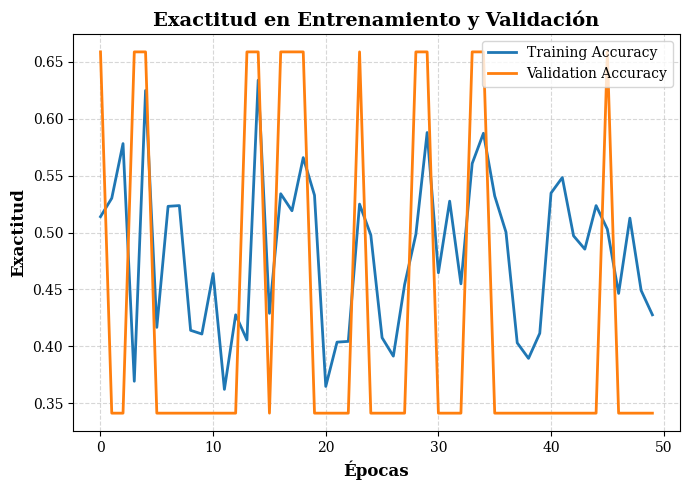

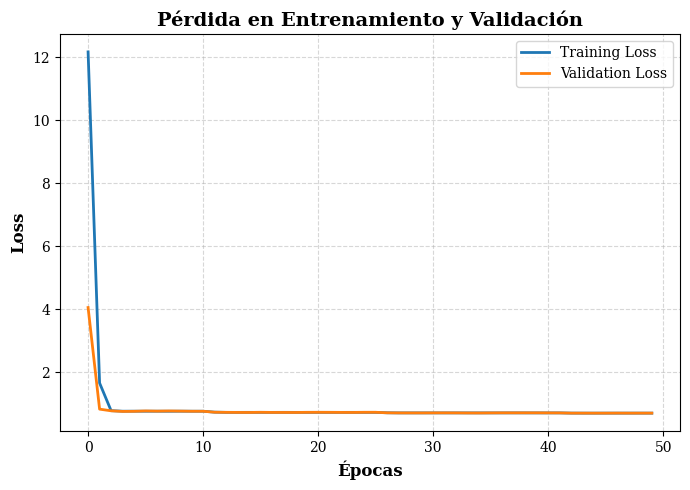

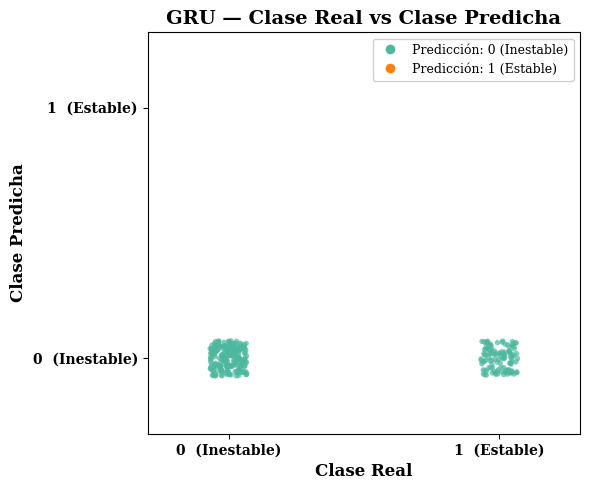

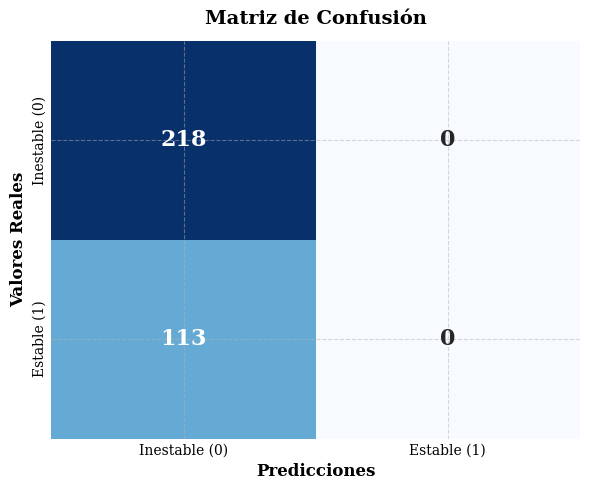

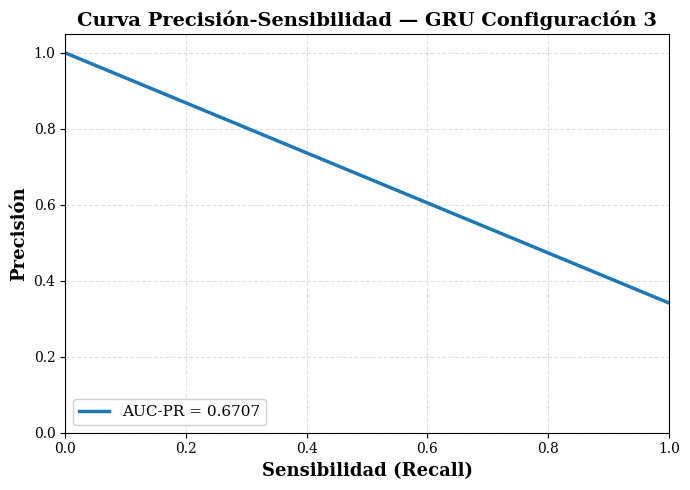

In [30]:
# ── Evaluación GRU Exp. 3 (conjunto de validación) ───────────────────────────────────
predictions_gru_3     = model_gru_3.predict(x_val, verbose=0)
pred_labels_gru_3     = (predictions_gru_3 > 0.5).astype(int)

accuracy_gru_3  = accuracy_score(y_val, pred_labels_gru_3)
precision_gru_3 = precision_score(y_val, pred_labels_gru_3, zero_division=0)
recall_gru_3    = recall_score(y_val, pred_labels_gru_3, zero_division=0)
f1_gru_3        = f1_score(y_val, pred_labels_gru_3, zero_division=0)
cm_gru_3        = confusion_matrix(y_val, pred_labels_gru_3)
prec_curve_gru_3, rec_curve_gru_3, _ = precision_recall_curve(y_val, predictions_gru_3.flatten())
auc_pr_gru_3    = auc(rec_curve_gru_3, prec_curve_gru_3)

print(f'GRU Exp 3 — Exactitud  (Accuracy):  {accuracy_gru_3:.4f}')
print(f'GRU Exp 3 — Precisión  (Precision): {precision_gru_3:.4f}')
print(f'GRU Exp 3 — Recall:                 {recall_gru_3:.4f}')
print(f'GRU Exp 3 — F1-Score:               {f1_gru_3:.4f}')
print(f'GRU Exp 3 — AUC-PR:                 {auc_pr_gru_3:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_3.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_gru_3.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_3.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_gru_3.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_gru_3.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_gru_3))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_gru_3.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'GRU — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_gru_3, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_gru_3, prec_curve_gru_3,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_gru_3:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — GRU Configuración 3',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### GRU — Configuración 4

Se extiende el entrenamiento a 100 épocas y se elimina L2, 
dejando solo L1 para promover sparsity en los pesos de la red más profunda.


In [31]:
# ── Experimento 4 GRU ───────────────────────────────────────────────────────
optimizer_gru_4 = Adam(learning_rate=0.002)
model_gru_4 = Sequential(name='gru_exp4')
model_gru_4.add(GRU(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l1(0.01)))
model_gru_4.add(Dropout(0.4))
model_gru_4.add(GRU(64, return_sequences=True, kernel_regularizer=regularizers.l1(0.01)))
model_gru_4.add(Dropout(0.4))
model_gru_4.add(GRU(64, return_sequences=False, kernel_regularizer=regularizers.l1(0.01)))
model_gru_4.add(Dropout(0.4))
model_gru_4.add(Dense(32, activation='relu'))
model_gru_4.add(Dense(1, activation='sigmoid'))
model_gru_4.compile(optimizer=optimizer_gru_4,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_gru_4 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  GRU — Experimento 4  |  Dispositivo: {DEVICE}')
print(f'  lr=0.002 | épocas=100 | capas=3 | dropout=0.4 | L1=0.01 | L2=0')
print(f'{"="*55}')
history_gru_4 = model_gru_4.fit(
    x_train, y_train,
    epochs=100,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_gru_4,
    verbose=1
)

model_gru_4.save(f'models/modelo_gru_exp4.keras')
print(f'\nModelo guardado: models/modelo_gru_exp4.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  GRU — Experimento 4  |  Dispositivo: cuda
  lr=0.002 | épocas=100 | capas=3 | dropout=0.4 | L1=0.01 | L2=0
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 290ms/step - accuracy: 0.4730 - loss: 16.5418 - val_accuracy: 0.6586 - val_loss: 4.0148 - learning_rate: 0.0020
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.5671 - loss: 2.4558 - val_accuracy: 0.6586 - val_loss: 0.8239 - learning_rate: 0.0020
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.4963 - loss: 0.8014 - val_accuracy: 0.6586 - val_loss: 0.7538 - learning_rate: 0.0020
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.6629 - loss: 0.7588 - val_accuracy: 0.3414 - val_loss: 0.7646 - learning_rate: 0.0020
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step - accuracy: 0.3738 - loss: 0.7625 - val_accuracy: 0.6586 - val_loss: 0.7586 - learning_rate: 0.0020
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.6079 - loss: 0.7567 - val_accuracy: 0.3414 - val_lo

GRU Exp 4 — Exactitud  (Accuracy):  0.3414
GRU Exp 4 — Precisión  (Precision): 0.3414
GRU Exp 4 — Recall:                 1.0000
GRU Exp 4 — F1-Score:               0.5090
GRU Exp 4 — AUC-PR:                 0.6707


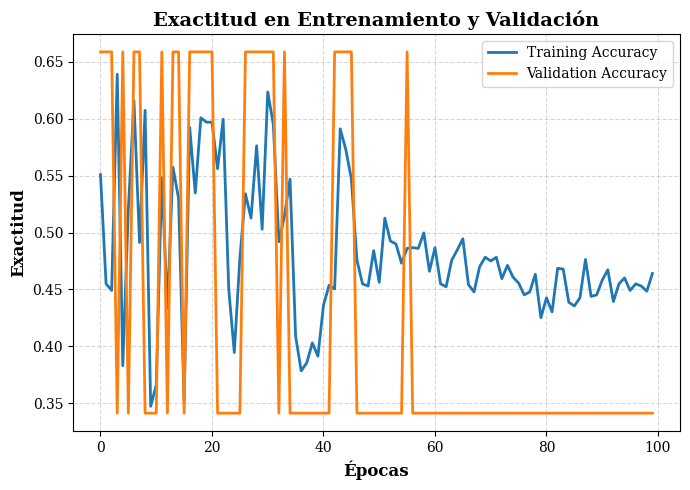

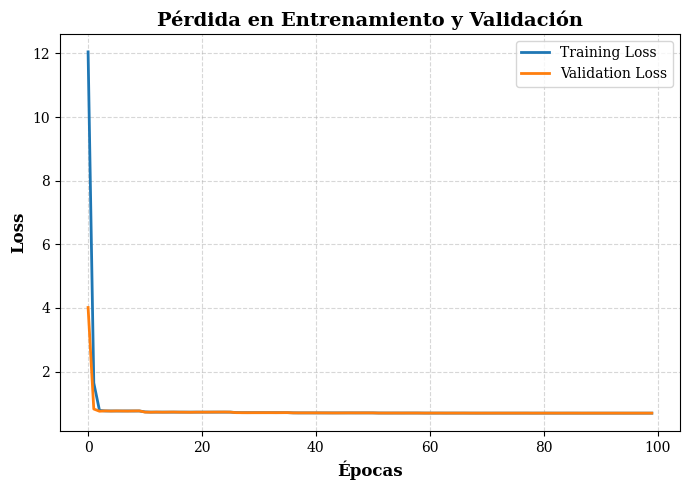

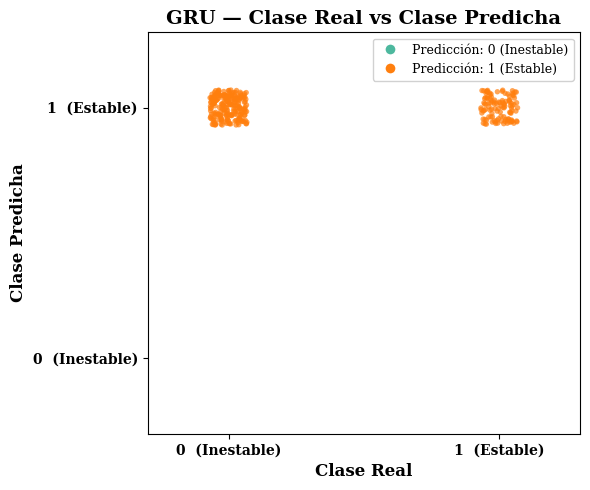

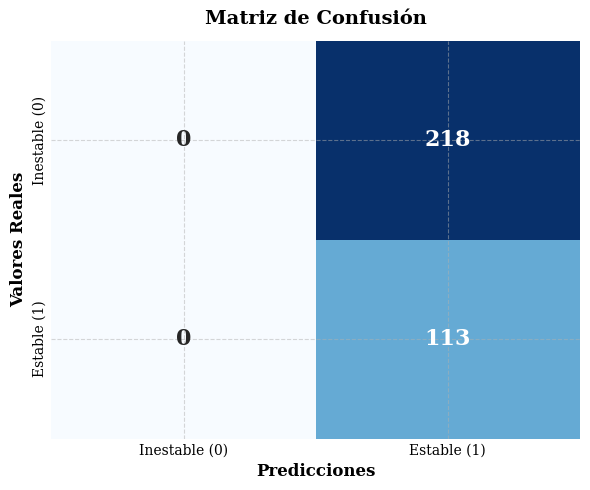

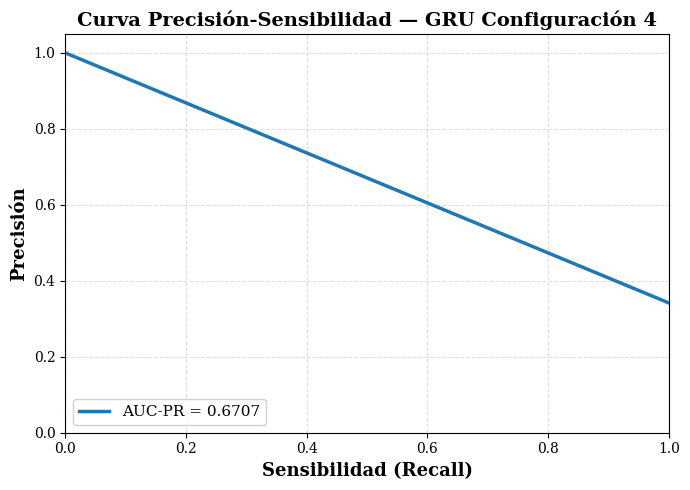

In [32]:
# ── Evaluación GRU Exp. 4 (conjunto de validación) ───────────────────────────────────
predictions_gru_4     = model_gru_4.predict(x_val, verbose=0)
pred_labels_gru_4     = (predictions_gru_4 > 0.5).astype(int)

accuracy_gru_4  = accuracy_score(y_val, pred_labels_gru_4)
precision_gru_4 = precision_score(y_val, pred_labels_gru_4, zero_division=0)
recall_gru_4    = recall_score(y_val, pred_labels_gru_4, zero_division=0)
f1_gru_4        = f1_score(y_val, pred_labels_gru_4, zero_division=0)
cm_gru_4        = confusion_matrix(y_val, pred_labels_gru_4)
prec_curve_gru_4, rec_curve_gru_4, _ = precision_recall_curve(y_val, predictions_gru_4.flatten())
auc_pr_gru_4    = auc(rec_curve_gru_4, prec_curve_gru_4)

print(f'GRU Exp 4 — Exactitud  (Accuracy):  {accuracy_gru_4:.4f}')
print(f'GRU Exp 4 — Precisión  (Precision): {precision_gru_4:.4f}')
print(f'GRU Exp 4 — Recall:                 {recall_gru_4:.4f}')
print(f'GRU Exp 4 — F1-Score:               {f1_gru_4:.4f}')
print(f'GRU Exp 4 — AUC-PR:                 {auc_pr_gru_4:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_4.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_gru_4.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_4.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_gru_4.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_gru_4.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_gru_4))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_gru_4.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'GRU — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_gru_4, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_gru_4, prec_curve_gru_4,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_gru_4:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — GRU Configuración 4',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

### GRU — Configuración 5

Tasa de aprendizaje alta (0.005) con regularización L2 exclusivamente. 
Busca explorar si un aprendizaje más agresivo con suavización L2 
produce resultados competitivos en 100 épocas.


In [33]:
# ── Experimento 5 GRU ───────────────────────────────────────────────────────
optimizer_gru_5 = Adam(learning_rate=0.005)
model_gru_5 = Sequential(name='gru_exp5')
model_gru_5.add(GRU(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2]), kernel_regularizer=regularizers.l2(0.001)))
model_gru_5.add(Dropout(0.4))
model_gru_5.add(GRU(64, return_sequences=True, kernel_regularizer=regularizers.l2(0.001)))
model_gru_5.add(Dropout(0.4))
model_gru_5.add(GRU(64, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
model_gru_5.add(Dropout(0.4))
model_gru_5.add(Dense(32, activation='relu'))
model_gru_5.add(Dense(1, activation='sigmoid'))
model_gru_5.compile(optimizer=optimizer_gru_5,
                        loss='binary_crossentropy', metrics=['accuracy'])

callbacks_gru_5 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print(f'\n{"="*55}')
print(f'  GRU — Experimento 5  |  Dispositivo: {DEVICE}')
print(f'  lr=0.005 | épocas=100 | capas=3 | dropout=0.4 | L1=0 | L2=0.001')
print(f'{"="*55}')
history_gru_5 = model_gru_5.fit(
    x_train, y_train,
    epochs=100,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_gru_5,
    verbose=1
)

model_gru_5.save(f'models/modelo_gru_exp5.keras')
print(f'\nModelo guardado: models/modelo_gru_exp5.keras')

c:\Users\Carlos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  GRU — Experimento 5  |  Dispositivo: cuda
  lr=0.005 | épocas=100 | capas=3 | dropout=0.4 | L1=0 | L2=0.001
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.5270 - loss: 0.8276 - val_accuracy: 0.6314 - val_loss: 0.5820 - learning_rate: 0.0050
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 283ms/step - accuracy: 0.6449 - loss: 0.6336 - val_accuracy: 0.6616 - val_loss: 0.6273 - learning_rate: 0.0050
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.6550 - loss: 0.6112 - val_accuracy: 0.6284 - val_loss: 0.5587 - learning_rate: 0.0050
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step - accuracy: 0.6876 - loss: 0.5933 - val_accuracy: 0.7946 - val_loss: 0.5589 - learning_rate: 0.0050
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.7012 - loss: 0.5850 - val_accuracy: 0.6314 - val_loss: 0.6515 - learning_rate: 0.0050
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step - accuracy: 0.6776 - loss: 0.5954 - val_accuracy: 0.7281 - val_lo

GRU Exp 5 — Exactitud  (Accuracy):  0.9426
GRU Exp 5 — Precisión  (Precision): 0.9052
GRU Exp 5 — Recall:                 0.9292
GRU Exp 5 — F1-Score:               0.9170
GRU Exp 5 — AUC-PR:                 0.9780


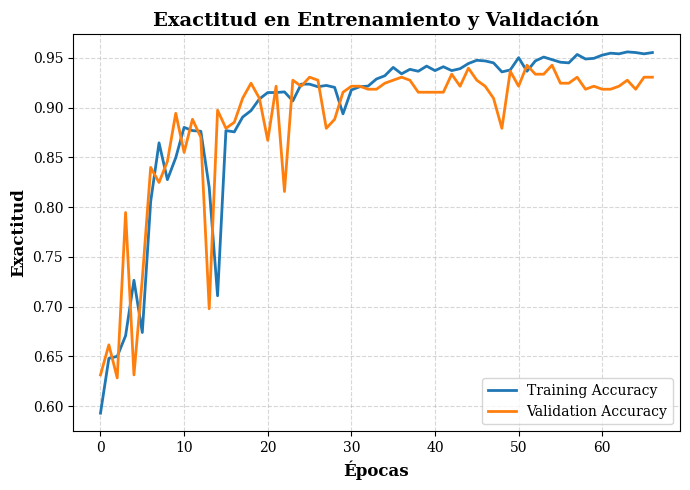

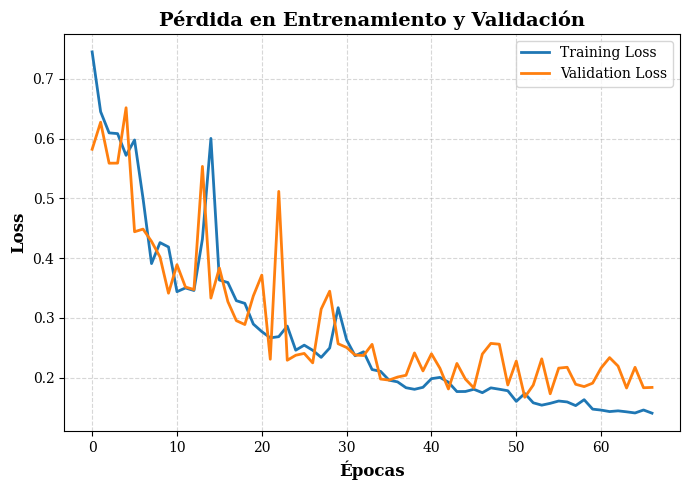

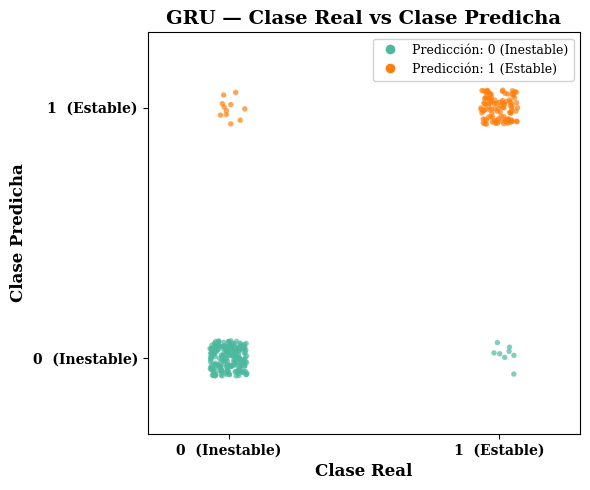

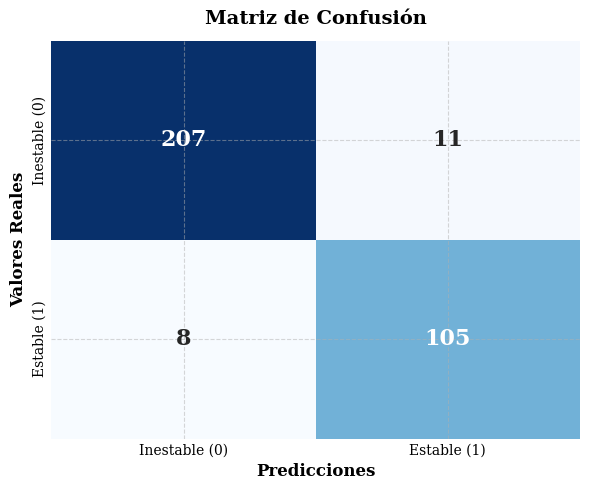

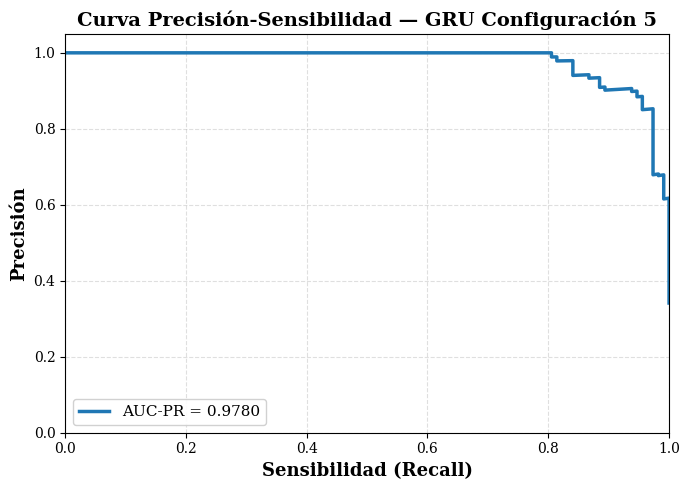

In [34]:
# ── Evaluación GRU Exp. 5 (conjunto de validación) ───────────────────────────────────
predictions_gru_5     = model_gru_5.predict(x_val, verbose=0)
pred_labels_gru_5     = (predictions_gru_5 > 0.5).astype(int)

accuracy_gru_5  = accuracy_score(y_val, pred_labels_gru_5)
precision_gru_5 = precision_score(y_val, pred_labels_gru_5, zero_division=0)
recall_gru_5    = recall_score(y_val, pred_labels_gru_5, zero_division=0)
f1_gru_5        = f1_score(y_val, pred_labels_gru_5, zero_division=0)
cm_gru_5        = confusion_matrix(y_val, pred_labels_gru_5)
prec_curve_gru_5, rec_curve_gru_5, _ = precision_recall_curve(y_val, predictions_gru_5.flatten())
auc_pr_gru_5    = auc(rec_curve_gru_5, prec_curve_gru_5)

print(f'GRU Exp 5 — Exactitud  (Accuracy):  {accuracy_gru_5:.4f}')
print(f'GRU Exp 5 — Precisión  (Precision): {precision_gru_5:.4f}')
print(f'GRU Exp 5 — Recall:                 {recall_gru_5:.4f}')
print(f'GRU Exp 5 — F1-Score:               {f1_gru_5:.4f}')
print(f'GRU Exp 5 — AUC-PR:                 {auc_pr_gru_5:.4f}')

# ── Fig 1: Exactitud en entrenamiento y validación ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_5.history['accuracy'],     color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(history_gru_5.history['val_accuracy'], color='#ff7f0e', lw=2, label='Validation Accuracy')
plt.title('Exactitud en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Exactitud', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 2: Pérdida en entrenamiento y validación ─────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(history_gru_5.history['loss'],     color='#1f77b4', lw=2, label='Training Loss')
plt.plot(history_gru_5.history['val_loss'], color='#ff7f0e', lw=2, label='Validation Loss')
plt.title('Pérdida en Entrenamiento y Validación', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Fig 3: Datos reales vs Predicciones — Jitter plot ────────────────────────
rng = np.random.default_rng(seed=42)
jit = 0.07   # dispersión en ambos ejes

x_real = y_val.flatten()                    + rng.uniform(-jit, jit, size=len(y_val))
y_pred = pred_labels_gru_5.flatten() + rng.uniform(-jit, jit, size=len(pred_labels_gru_5))

# Colorear cada punto según la predicción (verde=#4db89e → 0, naranja=#ff7f0e → 1)
colores = np.where(pred_labels_gru_5.flatten() == 0, '#4db89e', '#ff7f0e')

plt.figure(figsize=(6, 5))
plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4db89e', markersize=8, label='Predicción: 0 (Inestable)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='Predicción: 1 (Estable)'),
]
plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.title(f'GRU — Clase Real vs Clase Predicha', fontsize=14, fontweight='bold')
plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
plt.grid(False)
plt.tight_layout(); plt.show()

# ── Fig 4: Matriz de Confusión (validación) ─────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
# Dibujar el heatmap sin las líneas internas del grid
sns.heatmap(cm_gru_5, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inestable (0)', 'Estable (1)'],
            yticklabels=['Inestable (0)', 'Estable (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=0, linecolor='none',
            ax=ax_cm)
# Eliminar los ticks que generan líneas en los bordes de celda
ax_cm.tick_params(axis='both', which='both', length=0)
ax_cm.set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=12)
ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Fig 5: Curva Precisión-Sensibilidad individual ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(rec_curve_gru_5, prec_curve_gru_5,
         lw=2.5, color='#1f77b4', label=f'AUC-PR = {auc_pr_gru_5:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curva Precisión-Sensibilidad — GRU Configuración 5',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

## Curvas Precisión-Sensibilidad — comparativa GRU

Comparación del AUC-PR entre las 5 configuraciones GRU 
sobre el conjunto de validación.


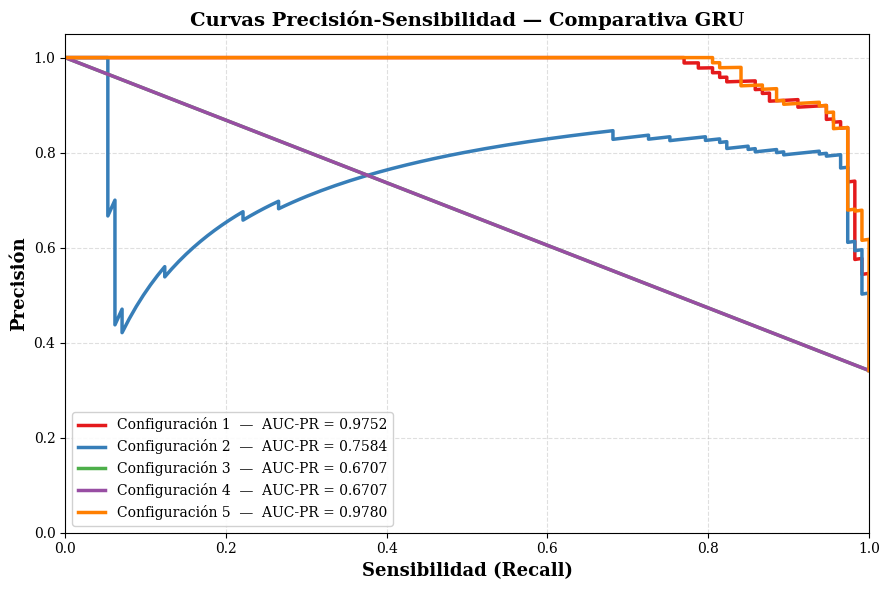


GRU — AUC-PR (conjunto de validación):
  Configuración 1: 0.9752
  Configuración 2: 0.7584
  Configuración 3: 0.6707
  Configuración 4: 0.6707
  Configuración 5: 0.9780


In [35]:
# ── Curva Precisión-Sensibilidad comparativa — GRU ───────────────────────────────────
plt.figure(figsize=(9, 6))
plt.plot(rec_curve_gru_1, prec_curve_gru_1, lw=2.5, color='#e41a1c',
         label=f'Configuración 1  —  AUC-PR = {auc_pr_gru_1:.4f}')
plt.plot(rec_curve_gru_2, prec_curve_gru_2, lw=2.5, color='#377eb8',
         label=f'Configuración 2  —  AUC-PR = {auc_pr_gru_2:.4f}')
plt.plot(rec_curve_gru_3, prec_curve_gru_3, lw=2.5, color='#4daf4a',
         label=f'Configuración 3  —  AUC-PR = {auc_pr_gru_3:.4f}')
plt.plot(rec_curve_gru_4, prec_curve_gru_4, lw=2.5, color='#984ea3',
         label=f'Configuración 4  —  AUC-PR = {auc_pr_gru_4:.4f}')
plt.plot(rec_curve_gru_5, prec_curve_gru_5, lw=2.5, color='#ff7f00',
         label=f'Configuración 5  —  AUC-PR = {auc_pr_gru_5:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
plt.title('Curvas Precisión-Sensibilidad — Comparativa GRU',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout(); plt.show()

print('\nGRU — AUC-PR (conjunto de validación):')
for _i in range(1, 6):
    print(f'  Configuración {_i}: {globals()["auc_pr_gru_" + str(_i)]:.4f}')

---

## Tabla resumen de resultados

Consolidación de las métricas obtenidas por todos los modelos 
sobre el **conjunto de validación (15%)**.

Las métricas reportadas son:
- **Exactitud** — porcentaje de predicciones correctas sobre el total
- **Precisión** — de las predicciones positivas, cuántas fueron correctas
- **Recall** — de los positivos reales, cuántos fueron detectados
- **F1-Score** — media armónica entre Precisión y Recall
- **AUC-PR** — área bajo la curva Precisión-Sensibilidad


In [36]:
# ── Tabla resumen de resultados — conjunto de validación ────────────────────────
rows = []
for mt in ['lstm', 'gru']:
    for i in range(1, 6):
        rows.append({
            'Modelo':      mt.upper(),
            'Experimento': f'Exp. {i}',
            'Exactitud':   globals()[f'accuracy_{mt}_{i}'],
            'Precisión':   globals()[f'precision_{mt}_{i}'],
            'Recall':      globals()[f'recall_{mt}_{i}'],
            'F1-Score':    globals()[f'f1_{mt}_{i}'],
            'AUC-PR':      globals()[f'auc_pr_{mt}_{i}'],
        })
df_results = pd.DataFrame(rows).round(4)
print(df_results.to_string(index=False))
df_results


Modelo Experimento  Exactitud  Precisión  Recall  F1-Score  AUC-PR
  LSTM      Exp. 1     0.9215     0.8783  0.8938    0.8860  0.9675
  LSTM      Exp. 2     0.8912     0.8182  0.8761    0.8462  0.7596
  LSTM      Exp. 3     0.8731     0.7591  0.9204    0.8320  0.7722
  LSTM      Exp. 4     0.3414     0.3414  1.0000    0.5090  0.6676
  LSTM      Exp. 5     0.9245     0.9314  0.8407    0.8837  0.9685
   GRU      Exp. 1     0.9366     0.8966  0.9204    0.9083  0.9752
   GRU      Exp. 2     0.9003     0.8030  0.9381    0.8653  0.7584
   GRU      Exp. 3     0.6586     0.0000  0.0000    0.0000  0.6707
   GRU      Exp. 4     0.3414     0.3414  1.0000    0.5090  0.6707
   GRU      Exp. 5     0.9426     0.9052  0.9292    0.9170  0.9780


,Modelo,Experimento,Exactitud,Precisión,Recall,F1-Score,AUC-PR
0,LSTM,Exp. 1,0.9215,0.8783,0.8938,0.8860,0.9675
1,LSTM,Exp. 2,0.8912,0.8182,0.8761,0.8462,0.7596
2,LSTM,Exp. 3,0.8731,0.7591,0.9204,0.8320,0.7722
3,LSTM,Exp. 4,0.3414,0.3414,1.0000,0.5090,0.6676
4,LSTM,Exp. 5,0.9245,0.9314,0.8407,0.8837,0.9685
5,GRU,Exp. 1,0.9366,0.8966,0.9204,0.9083,0.9752
6,GRU,Exp. 2,0.9003,0.8030,0.9381,0.8653,0.7584
7,GRU,Exp. 3,0.6586,0.0000,0.0000,0.0000,0.6707
8,GRU,Exp. 4,0.3414,0.3414,1.0000,0.5090,0.6707
9,GRU,Exp. 5,0.9426,0.9052,0.9292,0.9170,0.9780


---

# Backtesting — Evaluación sobre datos no vistos

El conjunto de **backtesting** representa el **15% de los datos que nunca 
fue expuesto al modelo** durante el entrenamiento ni la validación. 
Su propósito es simular el comportamiento del modelo frente a datos completamente nuevos, 
tal como ocurriría en una implementación real del sistema.

> ⚠️ **Esta sección debe ejecutarse únicamente después de que todos los modelos 
> hayan terminado su entrenamiento.** Hacerlo antes podría generar una evaluación 
> optimista al haber tomado decisiones de diseño basadas en esos datos.

**Resumen de la partición utilizada:**

| Subconjunto    | Proporción | Rol en el proceso                              |
|----------------|------------|------------------------------------------------|
| Entrenamiento  | 70 %       | Ajuste de pesos mediante backpropagation       |
| Validación     | 15 %       | Monitoreo de sobreajuste durante el entrenamiento |
| **Backtesting**| **15 %**   | **Evaluación final sobre datos nunca vistos**  |


In [37]:
# ── Backtesting — evaluación final en conjunto de prueba independiente (15%) ──
# x_backtest / y_backtest: datos que NUNCA fueron vistos durante el entrenamiento.

print('=' * 65)
print('  BACKTESTING — Conjunto de prueba independiente (15%)')
print(f'  Total muestras: {x_backtest.shape[0]}')
print(f'  Dispositivo: {DEVICE}')
print('=' * 65)

rows_bt = []
for mt in ['lstm', 'gru']:
    for exp in range(1, 6):
        key   = f'{mt}_exp{exp}'
        model = globals().get(f'model_{mt}_{exp}')
        if model is None:
            print(f'  [!] modelo_{mt}_exp{exp} no encontrado en memoria — omitido')
            continue

        preds  = model.predict(x_backtest, verbose=0)
        labels = (preds > 0.5).astype(int)

        prec_c, rec_c, _ = precision_recall_curve(y_backtest, preds.flatten())
        auc_pr_bt = auc(rec_c, prec_c)

        row = {
            'Modelo':      mt.upper(),
            'Experimento': f'Exp. {exp}',
            'Exactitud':   round(accuracy_score(y_backtest, labels), 4),
            'Precisión':   round(precision_score(y_backtest, labels, zero_division=0), 4),
            'Recall':      round(recall_score(y_backtest, labels, zero_division=0), 4),
            'F1-Score':    round(f1_score(y_backtest, labels, zero_division=0), 4),
            'AUC-PR':      round(auc_pr_bt, 4),
        }
        rows_bt.append(row)
        print(f'  {mt.upper()} Exp {exp} — Exactitud={row["Exactitud"]:.4f} | '
              f'F1={row["F1-Score"]:.4f} | AUC-PR={row["AUC-PR"]:.4f}')

df_backtest = pd.DataFrame(rows_bt)
print()
print(df_backtest.to_string(index=False))
df_backtest


  BACKTESTING — Conjunto de prueba independiente (15%)
  Total muestras: 331
  Dispositivo: cuda
  LSTM Exp 1 — Exactitud=0.9124 | F1=0.8711 | AUC-PR=0.9704
  LSTM Exp 2 — Exactitud=0.9003 | F1=0.8559 | AUC-PR=0.8343
  LSTM Exp 3 — Exactitud=0.9154 | F1=0.8852 | AUC-PR=0.8530
  LSTM Exp 4 — Exactitud=0.3444 | F1=0.5124 | AUC-PR=0.6382
  LSTM Exp 5 — Exactitud=0.9305 | F1=0.8920 | AUC-PR=0.9731
  GRU Exp 1 — Exactitud=0.9456 | F1=0.9189 | AUC-PR=0.9857
  GRU Exp 2 — Exactitud=0.8882 | F1=0.8452 | AUC-PR=0.8466
  GRU Exp 3 — Exactitud=0.6556 | F1=0.0000 | AUC-PR=0.6722
  GRU Exp 4 — Exactitud=0.3444 | F1=0.5124 | AUC-PR=0.6722
  GRU Exp 5 — Exactitud=0.9517 | F1=0.9286 | AUC-PR=0.9870

Modelo Experimento  Exactitud  Precisión  Recall  F1-Score  AUC-PR
  LSTM      Exp. 1     0.9124     0.8829  0.8596    0.8711  0.9704
  LSTM      Exp. 2     0.9003     0.8522  0.8596    0.8559  0.8343
  LSTM      Exp. 3     0.9154     0.8308  0.9474    0.8852  0.8530
  LSTM      Exp. 4     0.3444     0.344

,Modelo,Experimento,Exactitud,Precisión,Recall,F1-Score,AUC-PR
0,LSTM,Exp. 1,0.9124,0.8829,0.8596,0.8711,0.9704
1,LSTM,Exp. 2,0.9003,0.8522,0.8596,0.8559,0.8343
2,LSTM,Exp. 3,0.9154,0.8308,0.9474,0.8852,0.8530
3,LSTM,Exp. 4,0.3444,0.3444,1.0000,0.5124,0.6382
4,LSTM,Exp. 5,0.9305,0.9596,0.8333,0.8920,0.9731
5,GRU,Exp. 1,0.9456,0.9444,0.8947,0.9189,0.9857
6,GRU,Exp. 2,0.8882,0.8080,0.8860,0.8452,0.8466
7,GRU,Exp. 3,0.6556,0.0000,0.0000,0.0000,0.6722
8,GRU,Exp. 4,0.3444,0.3444,1.0000,0.5124,0.6722
9,GRU,Exp. 5,0.9517,0.9455,0.9123,0.9286,0.9870


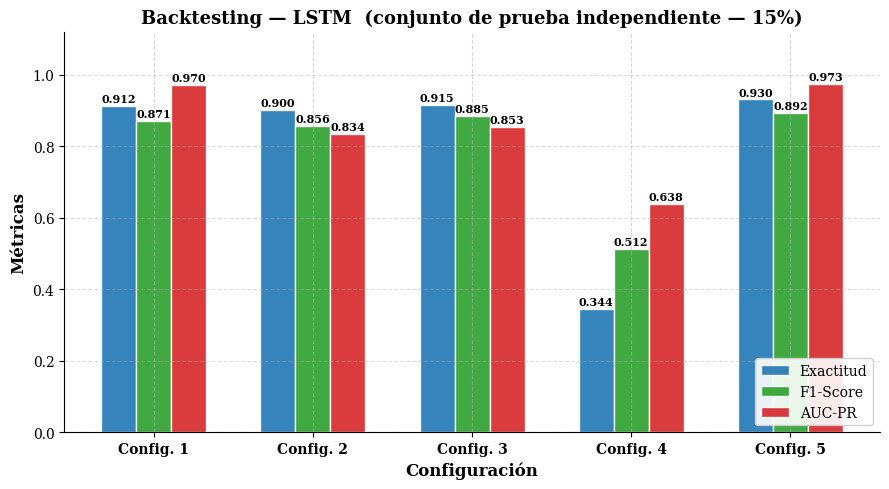

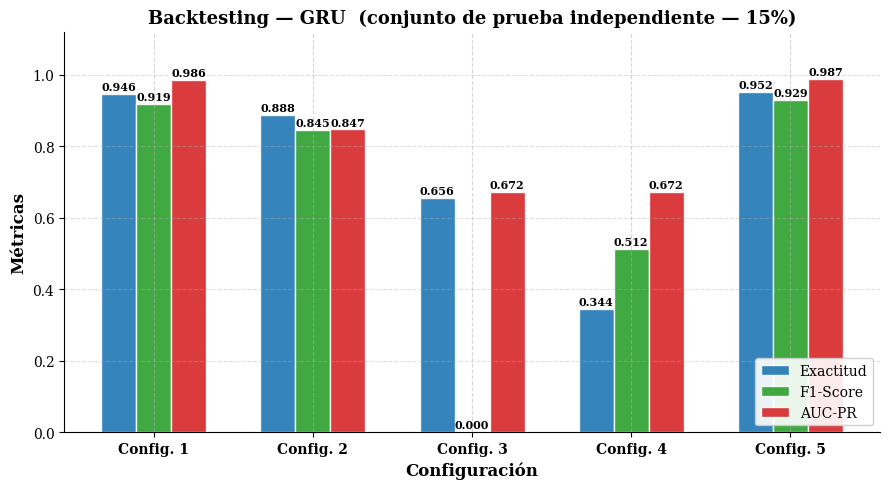


Métricas completas — Backtesting (15%):
Modelo Experimento  Exactitud  Precisión  Recall  F1-Score  AUC-PR
  LSTM      Exp. 1     0.9124     0.8829  0.8596    0.8711  0.9704
  LSTM      Exp. 2     0.9003     0.8522  0.8596    0.8559  0.8343
  LSTM      Exp. 3     0.9154     0.8308  0.9474    0.8852  0.8530
  LSTM      Exp. 4     0.3444     0.3444  1.0000    0.5124  0.6382
  LSTM      Exp. 5     0.9305     0.9596  0.8333    0.8920  0.9731
   GRU      Exp. 1     0.9456     0.9444  0.8947    0.9189  0.9857
   GRU      Exp. 2     0.8882     0.8080  0.8860    0.8452  0.8466
   GRU      Exp. 3     0.6556     0.0000  0.0000    0.0000  0.6722
   GRU      Exp. 4     0.3444     0.3444  1.0000    0.5124  0.6722
   GRU      Exp. 5     0.9517     0.9455  0.9123    0.9286  0.9870


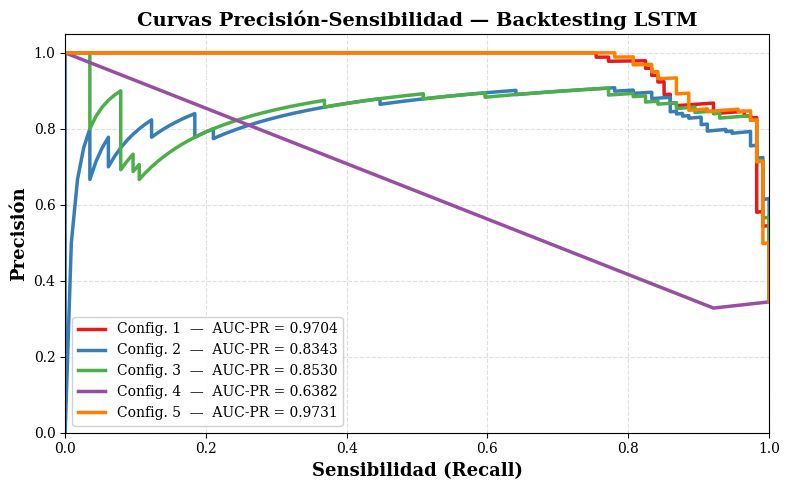

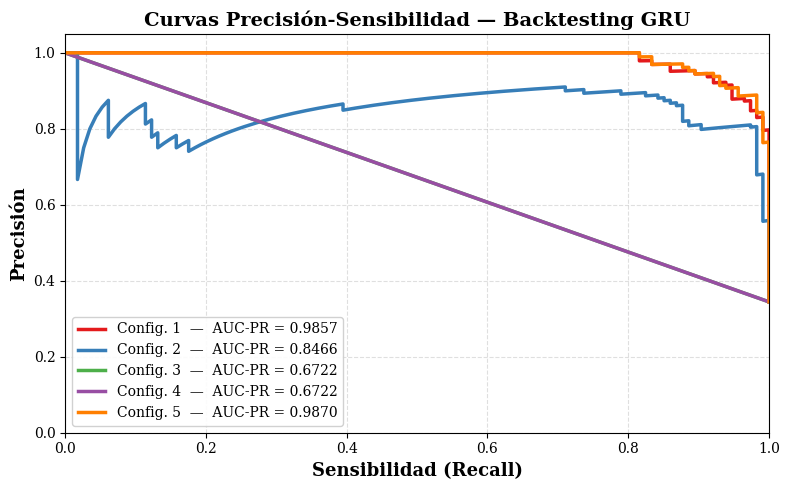

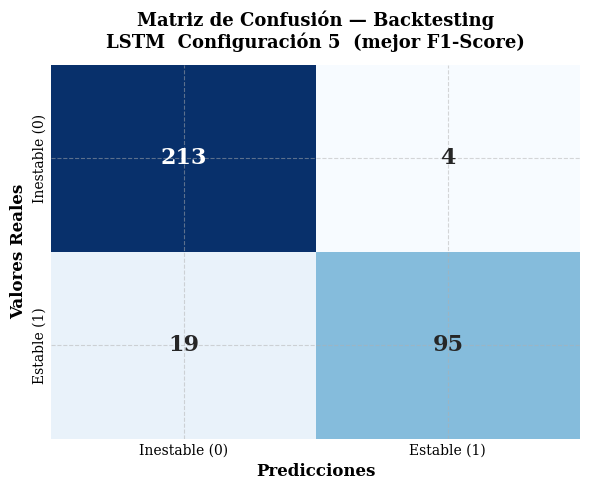

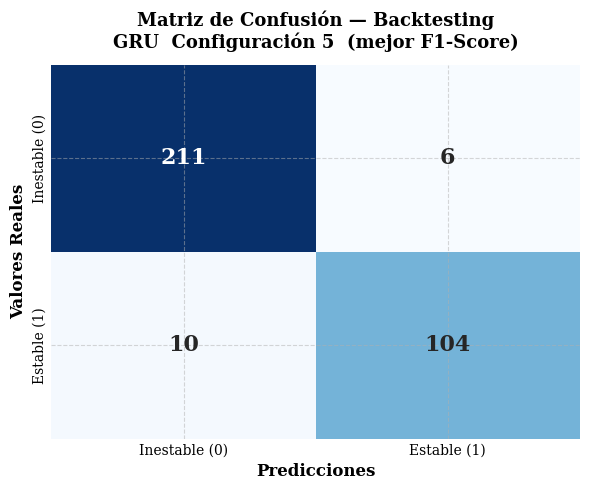

In [38]:
# ── Gráfica 1: Barras comparativas — Exactitud, F1-Score y AUC-PR ─────────────
for mt in ['lstm', 'gru']:
    MT     = mt.upper()
    subset = df_backtest[df_backtest['Modelo'] == MT].reset_index(drop=True)
    x_pos  = np.arange(len(subset))
    ancho  = 0.22
    etiquetas = [f'Config. {i+1}' for i in range(len(subset))]

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x_pos - ancho, subset['Exactitud'], ancho, label='Exactitud',
                color='#1f77b4', alpha=0.9, edgecolor='white')
    b2 = ax.bar(x_pos,         subset['F1-Score'],  ancho, label='F1-Score',
                color='#2ca02c', alpha=0.9, edgecolor='white')
    b3 = ax.bar(x_pos + ancho, subset['AUC-PR'],    ancho, label='AUC-PR',
                color='#d62728', alpha=0.9, edgecolor='white')

    # Etiquetas de valor sobre cada barra
    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(etiquetas, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_title(f'Backtesting — {MT}  (conjunto de prueba independiente — 15%)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Configuración', fontsize=12, fontweight='bold')
    ax.set_ylabel('Métricas',      fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()

# ── Gráfica 2: Tabla de métricas completa ─────────────────────────────────────
print('\nMétricas completas — Backtesting (15%):')
print(df_backtest.to_string(index=False))

# ── Gráfica 3: Curvas Precisión-Sensibilidad por familia ──────────────────────
for mt in ['lstm', 'gru']:
    MT = mt.upper()
    plt.figure(figsize=(8, 5))
    for exp, c in zip(range(1, 6), ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']):
        model = globals().get(f'model_{mt}_{exp}')
        if model is None:
            continue
        preds_bt = model.predict(x_backtest, verbose=0)
        pc, rc, _ = precision_recall_curve(y_backtest, preds_bt.flatten())
        auc_v     = auc(rc, pc)
        plt.plot(rc, pc, lw=2.5, color=c, label=f'Config. {exp}  —  AUC-PR = {auc_v:.4f}')

    plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
    plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
    plt.title(f'Curvas Precisión-Sensibilidad — Backtesting {MT}',
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=10, framealpha=0.9)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.tight_layout(); plt.show()

# ── Gráfica 4: Matriz de Confusión — mejor configuración por familia ───────────
for mt in ['lstm', 'gru']:
    MT       = mt.upper()
    best_row = df_backtest[df_backtest['Modelo'] == MT].sort_values('F1-Score', ascending=False).iloc[0]
    best_exp = int(best_row['Experimento'].split('.')[1].strip())
    model    = globals()[f'model_{mt}_{best_exp}']

    preds_bt  = model.predict(x_backtest, verbose=0)
    labels_bt = (preds_bt > 0.5).astype(int)
    cm_bt     = confusion_matrix(y_backtest, labels_bt)

    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_bt, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Inestable (0)', 'Estable (1)'],
                yticklabels=['Inestable (0)', 'Estable (1)'],
                annot_kws={'size': 16, 'fontweight': 'bold'},
                linewidths=0, linecolor='none', ax=ax_cm)
    ax_cm.tick_params(axis='both', which='both', length=0)
    ax_cm.set_title(
        f'Matriz de Confusión — Backtesting\n{MT}  Configuración {best_exp}  (mejor F1-Score)',
        fontsize=13, fontweight='bold', pad=12)
    ax_cm.set_xlabel('Predicciones',  fontsize=12, fontweight='bold')
    ax_cm.set_ylabel('Valores Reales', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


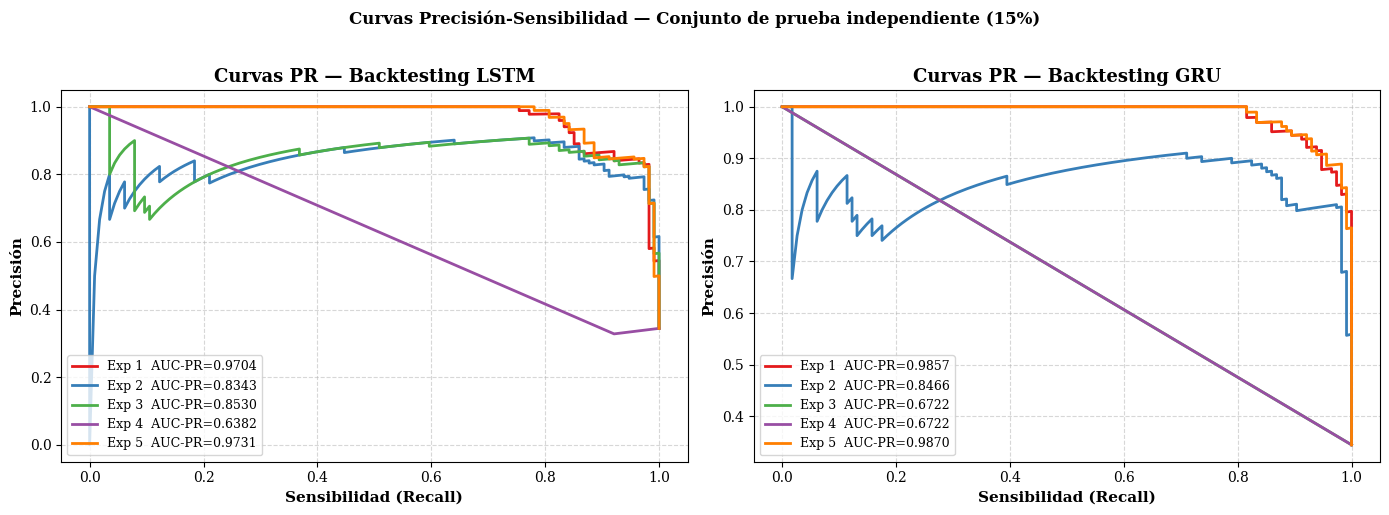

In [39]:
# ── Curvas PR — backtesting comparativo (LSTM y GRU) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

for ax, mt in zip(axes, ['lstm', 'gru']):
    MT = mt.upper()
    for exp, c in zip(range(1, 6), colors):
        model = globals().get(f'model_{mt}_{exp}')
        if model is None:
            continue
        preds_bt = model.predict(x_backtest, verbose=0)
        pc, rc, _ = precision_recall_curve(y_backtest, preds_bt.flatten())
        auc_v     = auc(rc, pc)
        ax.plot(rc, pc, lw=2, color=c, label=f'Exp {exp}  AUC-PR={auc_v:.4f}')

    ax.set_xlabel('Sensibilidad (Recall)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Precisión', fontsize=11, fontweight='bold')
    ax.set_title(f'Curvas PR — Backtesting {MT}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Curvas Precisión-Sensibilidad — Conjunto de prueba independiente (15%)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---

# Inferencia — Carga y evaluación de modelos guardados

Esta sección permite reproducir el backtesting completo a partir 
de los archivos `.keras` guardados, **sin necesidad de reentrenar** ningún modelo.

**Requisitos:**
- Carpeta `models/` en el mismo directorio que este notebook
- Los 10 archivos `.keras` generados durante el entrenamiento
- El tensor `x_backtest` y el vector `y_backtest` cargados en memoria
  (basta con ejecutar las celdas de carga de datos y división)


In [40]:
# ── Cargar modelos guardados (.keras) y ejecutar backtesting ──────────────────
# Ejecuta esta sección de forma INDEPENDIENTE (sin reentrenar).
# Requiere: carpeta 'models/' con los 10 archivos .keras
#           y que x_backtest / y_backtest estén en memoria.

from keras.models import load_model

modelos_inf = {}
for mt in ['lstm', 'gru']:
    for exp in range(1, 6):
        path = f'models/modelo_{mt}_exp{exp}.keras'
        try:
            m = load_model(path)
            modelos_inf[f'{mt}_exp{exp}'] = m
            print(f'✓ Cargado: {path}')
        except Exception as e:
            print(f'✗ No encontrado: {path} — {e}')
print(f'\nTotal modelos cargados: {len(modelos_inf)}')


✓ Cargado: models/modelo_lstm_exp1.keras
✓ Cargado: models/modelo_lstm_exp2.keras
✓ Cargado: models/modelo_lstm_exp3.keras
✓ Cargado: models/modelo_lstm_exp4.keras
✓ Cargado: models/modelo_lstm_exp5.keras
✓ Cargado: models/modelo_gru_exp1.keras
✓ Cargado: models/modelo_gru_exp2.keras
✓ Cargado: models/modelo_gru_exp3.keras
✓ Cargado: models/modelo_gru_exp4.keras
✓ Cargado: models/modelo_gru_exp5.keras

Total modelos cargados: 10


In [41]:
# ── Backtesting con modelos cargados (conjunto de prueba independiente — 15%) ──

rows_inf_bt = []
for key, modelo in modelos_inf.items():
    mt_k, exp_str = key.split('_exp')

    preds_inf = modelo.predict(x_backtest, verbose=0)
    labels_inf = (preds_inf > 0.5).astype(int)
    pc, rc, _  = precision_recall_curve(y_backtest, preds_inf.flatten())
    auc_v      = auc(rc, pc)

    rows_inf_bt.append({
        'Modelo':      mt_k.upper(),
        'Experimento': f'Exp. {exp_str}',
        'Exactitud':   round(accuracy_score(y_backtest, labels_inf), 4),
        'Precisión':   round(precision_score(y_backtest, labels_inf, zero_division=0), 4),
        'Recall':      round(recall_score(y_backtest, labels_inf, zero_division=0), 4),
        'F1-Score':    round(f1_score(y_backtest, labels_inf, zero_division=0), 4),
        'AUC-PR':      round(auc_v, 4),
    })

df_inf_bt = pd.DataFrame(rows_inf_bt)
print('Backtesting — modelos cargados desde .keras:')
print(df_inf_bt.to_string(index=False))
df_inf_bt


Backtesting — modelos cargados desde .keras:
Modelo Experimento  Exactitud  Precisión  Recall  F1-Score  AUC-PR
  LSTM      Exp. 1     0.9124     0.8829  0.8596    0.8711  0.9704
  LSTM      Exp. 2     0.9003     0.8522  0.8596    0.8559  0.8343
  LSTM      Exp. 3     0.9154     0.8308  0.9474    0.8852  0.8530
  LSTM      Exp. 4     0.3444     0.3444  1.0000    0.5124  0.6382
  LSTM      Exp. 5     0.9305     0.9596  0.8333    0.8920  0.9731
   GRU      Exp. 1     0.9456     0.9444  0.8947    0.9189  0.9857
   GRU      Exp. 2     0.8882     0.8080  0.8860    0.8452  0.8466
   GRU      Exp. 3     0.6556     0.0000  0.0000    0.0000  0.6722
   GRU      Exp. 4     0.3444     0.3444  1.0000    0.5124  0.6722
   GRU      Exp. 5     0.9517     0.9455  0.9123    0.9286  0.9870


,Modelo,Experimento,Exactitud,Precisión,Recall,F1-Score,AUC-PR
0,LSTM,Exp. 1,0.9124,0.8829,0.8596,0.8711,0.9704
1,LSTM,Exp. 2,0.9003,0.8522,0.8596,0.8559,0.8343
2,LSTM,Exp. 3,0.9154,0.8308,0.9474,0.8852,0.8530
3,LSTM,Exp. 4,0.3444,0.3444,1.0000,0.5124,0.6382
4,LSTM,Exp. 5,0.9305,0.9596,0.8333,0.8920,0.9731
5,GRU,Exp. 1,0.9456,0.9444,0.8947,0.9189,0.9857
6,GRU,Exp. 2,0.8882,0.8080,0.8860,0.8452,0.8466
7,GRU,Exp. 3,0.6556,0.0000,0.0000,0.0000,0.6722
8,GRU,Exp. 4,0.3444,0.3444,1.0000,0.5124,0.6722
9,GRU,Exp. 5,0.9517,0.9455,0.9123,0.9286,0.9870
